In [1]:
# import libraries
from getpass import getpass
import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
from datetime import datetime,timedelta
from shapely.geometry import Polygon
from shapely.ops import unary_union
import rasterio
from rasterio.control import GroundControlPoint
from rasterio.crs import CRS
from rasterio.features import rasterize
from affine import Affine
import xml.etree.ElementTree as ET
import geopandas as gpd
import zipfile
import tempfile
import re
from eodms_api_client import EodmsAPI
from scipy.interpolate import interp1d
import shutil
from netCDF4 import Dataset
from scipy.interpolate import griddata
from scipy.ndimage import map_coordinates
import pandas as pd
from shapely import wkt

c:\Users\Niloo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Retrieve, Search, and Download RCM Scenes based on Sentinel-1s' shapefiles

In [2]:
"""
For each Sentinel-1 shapefile, this block of code extracts a buffered time range (10 hours) based on the filename.  
It then queries the EODMS API for overlapping RCM scenes with HH and HV polarizations within that time window and area.  
The matching scenes are saved as a GeoJSON file, and a new RCM order is submitted using the selected scene IDs.
"""
 
# Sentinel-1 shapefile path
shapefile_folder = "./train_dataset_shapefiles/"
# shapefile_folder = "./test_dataset_shapefiles/"
records = []
best_matches_data = [] 
 
# get EODMS user credentials
username = input("EODMS username: ")
password = getpass("EODMS password: ")
 
# extract time range from Sentinel-1 filename
# create a time window of 10 hours (5h before, 5h after) to search for compatible RCM scenes
def extract_time_range(filename):
    match = re.search(r'_(\d{8}T\d{6})_(\d{8}T\d{6})_', filename)
    start = datetime.strptime(match.group(1), "%Y%m%dT%H%M%S")
    end = datetime.strptime(match.group(2), "%Y%m%dT%H%M%S")
    return (start - timedelta(hours=5)).strftime("%Y-%m-%dT%H:%M:%S"), (end + timedelta(hours=5)).strftime("%Y-%m-%dT%H:%M:%S")

for zip_file in sorted(os.listdir(shapefile_folder), key=lambda f: int(re.match(r'\d+', f).group())):
    zip_path = os.path.join(shapefile_folder, zip_file)
    print(f"\n{zip_file}")
 
    # extract time range and prefix
    start_date, end_date = extract_time_range(zip_file)
    print(f"Buffered Time Range: {start_date} to {end_date}")
    prefix_match = re.match(r"(\d+)_", zip_file)
    prefix = prefix_match.group(1) if prefix_match else "unknown"
 
    with tempfile.TemporaryDirectory() as tmpdir:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(tmpdir)
        shp_file = [f for f in os.listdir(tmpdir) if f.endswith('.shp')][0]
        shp_path = os.path.join(tmpdir, shp_file)
        geojson_path = shp_path.replace('.shp', '.geojson')
        gdf = gpd.read_file(shp_path)
        gdf.to_file(geojson_path, driver="GeoJSON")
 
        # connect to EODMS API and query
        client = EodmsAPI(collection='RCM', username=username, password=password)
        client.query(start=start_date, end=end_date, geometry=geojson_path)
        print(f"Found {len(client.results)} scenes.")
        if len(client.results) == 0:
            records.append({                    
                "shapefile": zip_file,
                "time_window": f"{start_date} – {end_date}",
                "num_RCM_scenes": 0
            })
            print("No scenes found")
            continue
 
        # filter by polarization (Only HH, HV)
        filtered = client.results[
            (client.results["Polarization in Product"].str.contains("HH") & client.results["Polarization in Product"].str.contains("HV")) &
            (client.results["Beam Mode Description"].str.contains("350km Swath", case=False, na=False)) &
            (client.results["Product Type"] == "GRD") &
            (client.results["LUT Applied"] == "Ice")
        ]
        
        print(f"The number of scenes with HH & HV channels: {len(filtered)}")
        
        records.append({
            "shapefile"  : zip_file,
            "time_window" : f"{start_date} – {end_date}",
            "num_RCM_scenes" : len(filtered)
        })
        print("\n--- Full Metadata for Filtered Scenes ---")
        print(filtered.to_string(index=False))

        if not filtered.empty:
            # Use the accurate Sentinel-1 footprint polygon (not bounding box)
            s1_geom = gdf.unary_union
    
            # RCM footprints (already Shapely polygons in filtered["geometry"])
            rcm_gdf = gpd.GeoDataFrame(filtered, geometry="geometry", crs=gdf.crs)
    
            # Compute intersection area directly
            rcm_gdf["intersection_area"] = rcm_gdf.geometry.apply(lambda rcm_geom: rcm_geom.intersection(s1_geom).area)
            rcm_gdf["rcm_area"] = rcm_gdf.geometry.apply(lambda geom: geom.area)
            rcm_gdf["overlap_percent"] = (rcm_gdf["intersection_area"] / rcm_gdf["rcm_area"]) * 100
    
            # Remove scenes with 0 overlap
            rcm_gdf = rcm_gdf[rcm_gdf["intersection_area"] > 0]
        else:
            print("No HH/HV scenes found in the filtered results.")

        # Get best overlapping RCM scene 
        if not rcm_gdf.empty:
            best_match = rcm_gdf.loc[rcm_gdf["intersection_area"].idxmax()]
            s1_area = s1_geom.area
            s1_overlap_percent = (best_match["intersection_area"] / s1_area) * 100
            print("\n Best Overlapping RCM Scene (by polygon intersection):")
            print(best_match[["Granule", "overlap_percent"]])

            # Save best match data for Excel
            meta_cols = [
                "Granule", "Beam Mnemonic", "Beam Mode Type", "Beam Mode Description", "Spatial Resolution", "Polarization Data Mode", "Polarization", "Polarization in Product", 
                "Incidence Angle (Low)", "Incidence Angle (High)", "Orbit Direction", "LUT Applied", "Product Format", "Product Type"
            ]
            print(best_match)
            row_data = {
                "Sentinel-1 shapefile": zip_file,
                "Overlap % (RCM with S1)": best_match["overlap_percent"],
                "Overlap % (S1 with RCM)": s1_overlap_percent,
            }
            for col in meta_cols:
                row_data[col] = best_match.get(col, "")

            best_matches_data.append(row_data)
        else:
            print("\n No overlapping RCM scenes found with valid intersection.")

        # Submit order
        best_record_id = best_match["EODMS RecordId"]
        order_ids = client.order([best_record_id])
        print(f"\n Submitted order for best match: Record ID {best_record_id}")
        print(f"Order ID: {order_ids[0]}")

        # Save order ID to file
        order_dir = "./order_ids"
        # order_dir = "./order_ids_test"
        os.makedirs(order_dir, exist_ok=True)
        order_file_path = os.path.join(order_dir, f"{prefix}_RCM.txt")
        with open(order_file_path, "w") as f:
            f.write(str(order_ids[0]))
 

# # Save all best match info to Excel
# df_best = pd.DataFrame(best_matches_data)
# df_best.to_excel("match_rcm_scenes_summary.xlsx", index=False)


442_S1B_EW_GRDM_1SDH_20210429T080105_20210429T080205_026679_032FAF_A971_icechart_dmi_202104290800_North_RIC.zip
Buffered Time Range: 2021-04-29T03:01:05 to 2021-04-29T13:02:05


2025-10-01 11:22:23 | pyogrio._io     | INFO     | Created 1 records
Fetching result metadata: 100%|██████████| 16/16 [00:01<00:00, 10.88item/s]
C:\Users\Niloo\AppData\Local\Temp\ipykernel_15968\3495571754.py:77: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  s1_geom = gdf.unary_union
2025-10-01 11:22:34 | eodmsapi.main   | INFO     | Submitting order for 1 item


Found 16 scenes.
The number of scenes with HH & HV channels: 8

--- Full Metadata for Filtered Scenes ---
 EODMS RecordId                                                     Granule    Acquisition Start Date      Acquisition End Date Satellite ID Beam Mnemonic        Beam Mode Type                Beam Mode Description  Beam Mode Version  Spatial Resolution Polarization Data Mode Polarization Polarization in Product  Number of Azimuth Looks  Number of Range Looks  Incidence Angle (Low)  Incidence Angle (High) Orbit Direction LUT Applied Product Format Product Type Product Ellipsoid        Sample Type  Sampled Pixel Spacing Data Type  SIP Size (MB)  Relative Orbit  Absolute Orbit Orbit Data Source                                                                                                                                                               thumbnailUrl                                                                                                       geometry
        88745

In [3]:
import time
from pathlib import Path

username = input("EODMS username: ")
password = getpass("EODMS password: ")
client = EodmsAPI(collection='RCM', username=username, password=password)
order_dir = "./order_ids"
# order_dir = "./order_ids_test"
rcm_download_root = "./RCM"
os.makedirs(rcm_download_root, exist_ok=True)

for order_file in os.listdir(order_dir):
    order_file_path = os.path.join(order_dir, order_file)
    order_id = int(Path(order_file_path).read_text().strip())

    prefix = order_file.split("_")[0]
    folder = os.path.join(rcm_download_root, f"{prefix}_RCM")
    os.makedirs(folder, exist_ok=True)

    if list(Path(folder).glob("*.zip")):
        print(f"Already downloaded: {prefix}")
        continue

    print(f"Downloading order {order_id} to {folder}")
    try:
        client.download([order_id], folder)
    except Exception as e:
        print(f"Failed once: {e}\nRetrying in 10s...")
        time.sleep(10)
        client.download([order_id], folder)

    if list(Path(folder).glob("*.zip")):
        print(f"Download complete: {prefix}")
    else:
        print(f"No file found in {folder}")


2025-10-01 13:07:35 | eodmsapi.main   | INFO     | Checking status of 1 order


2025-10-01 13:07:35 | eodmsapi.main   | INFO     | 1/1 items ready for download
2025-10-01 13:07:35 | eodmsapi.main   | INFO     | 0/1 items exist locally
2025-10-01 13:07:35 | eodmsapi.main   | INFO     | Downloading 1 remote item
RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD.zip: 100%|██████████| 857M/857M [00:30<00:00, 29.8MB/s] 
2025-10-01 13:08:06 | eodmsapi.main   | INFO     | 1/1 items exist locally after latest download


Download complete: 442


In [4]:
# unzip RCM compress files
for folder_name in os.listdir(rcm_download_root):
    folder_path = os.path.join(rcm_download_root, folder_name)
    if not os.path.isdir(folder_path):
        continue
    print(f"{folder_path}")
    for zip_name in os.listdir(folder_path):
        if zip_name.endswith(".zip"):
            zip_path = os.path.join(folder_path, zip_name)
            extract_folder = os.path.join(folder_path, zip_name.replace(".zip", ""))
            if not os.path.exists(extract_folder):
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(extract_folder)
                    print(f"Extracted:{zip_name}")
                os.remove(zip_path)

./RCM\442_RCM
Extracted:RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD.zip


Find the RCM scene with the Most Overlapping Area with Sentinel-1 (Comparing S1 & RCM polygons)

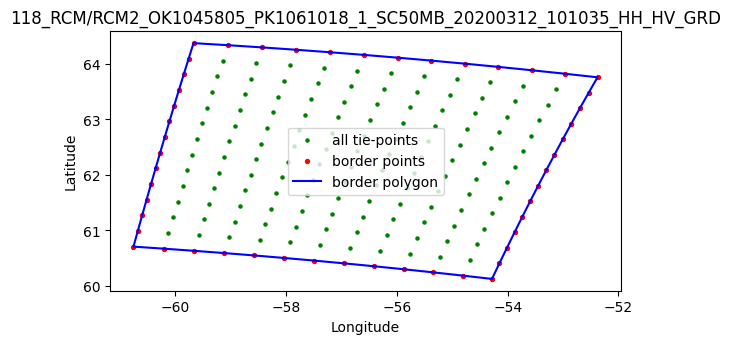

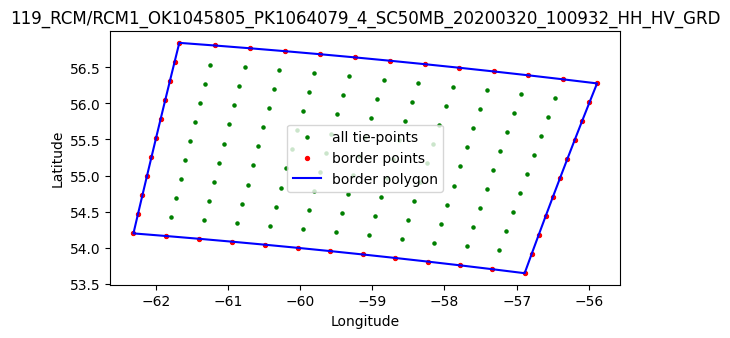

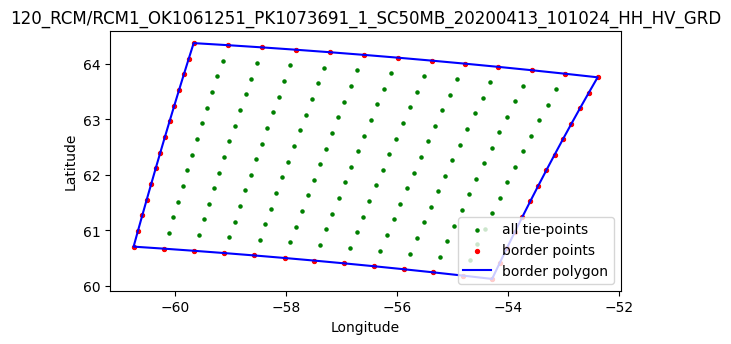

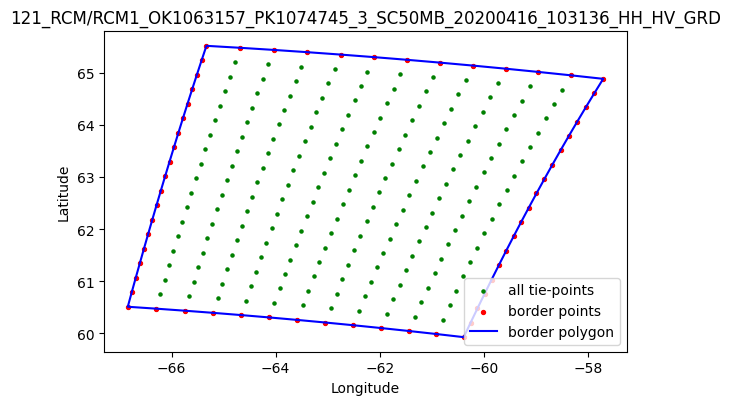

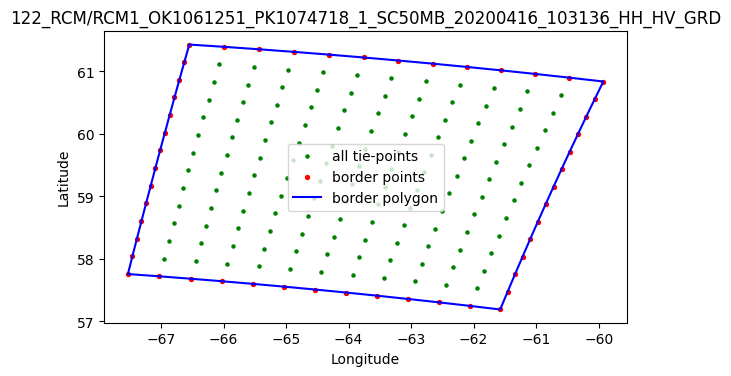

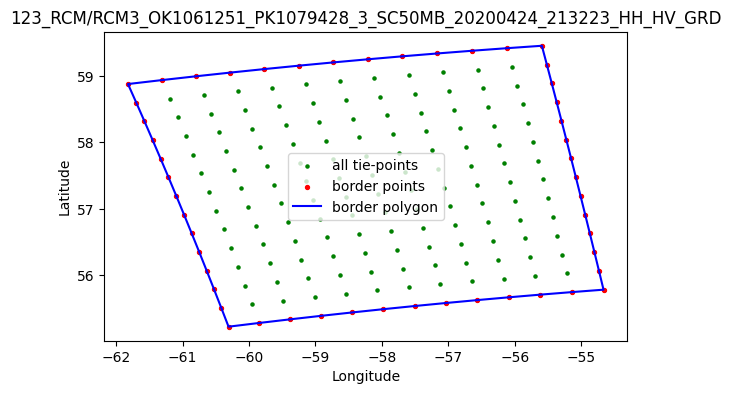

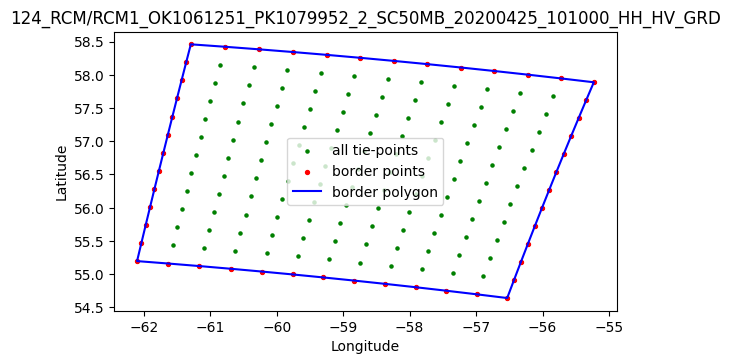

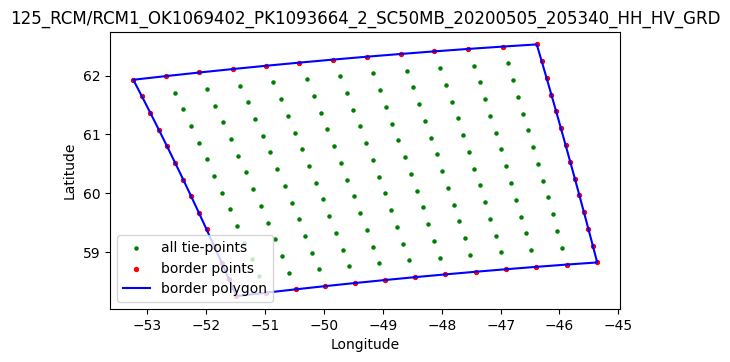

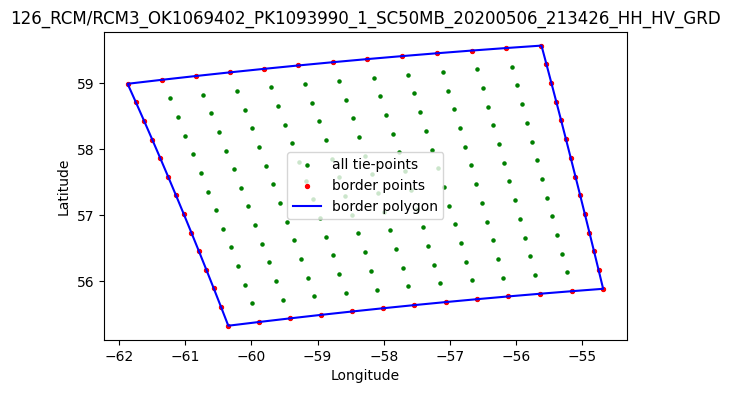

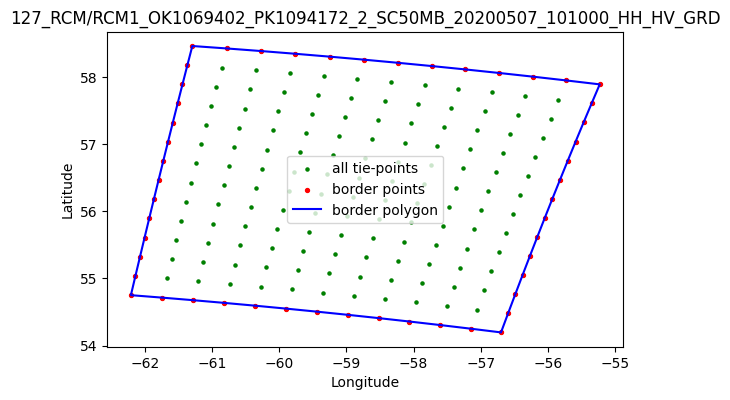

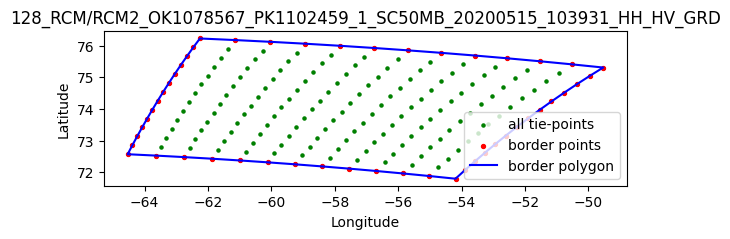

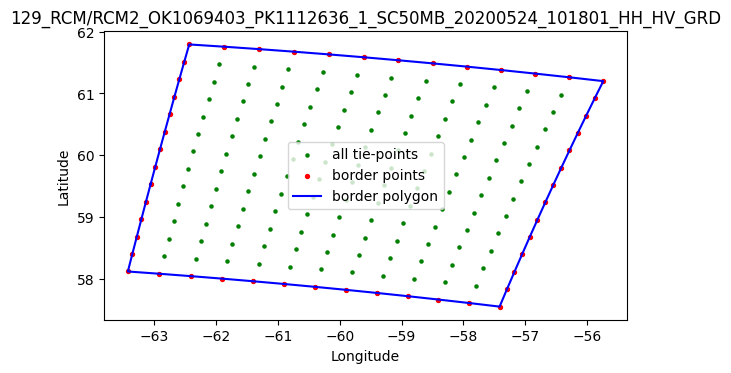

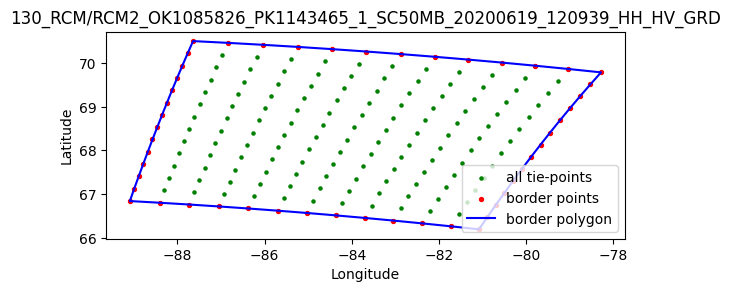

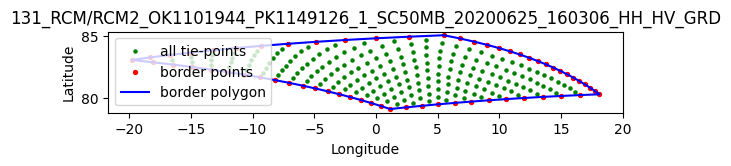

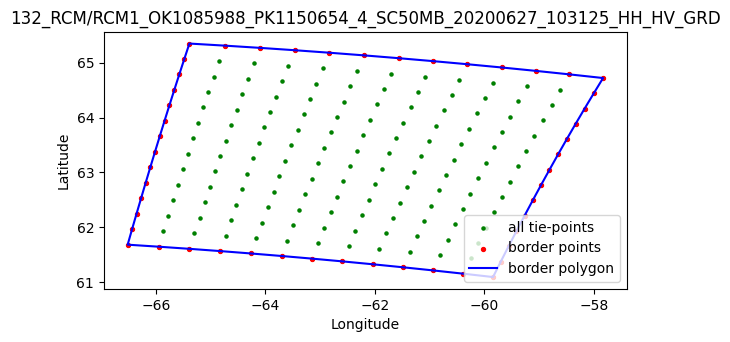

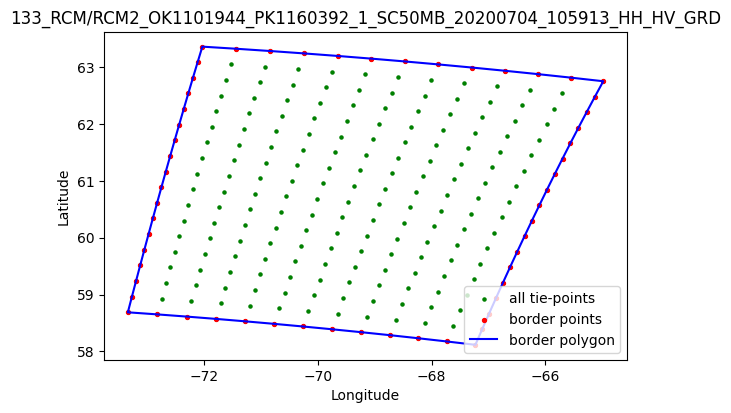

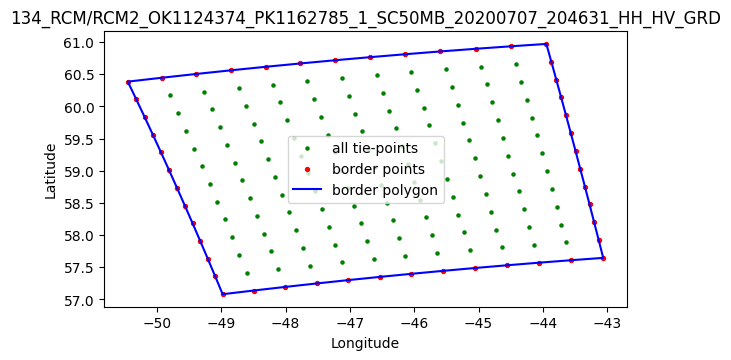

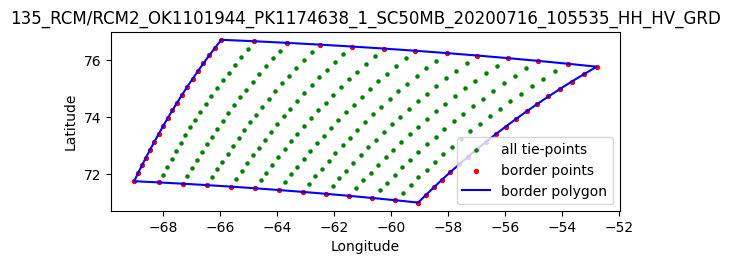

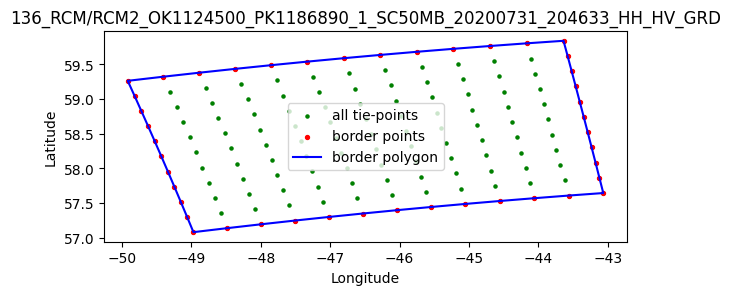

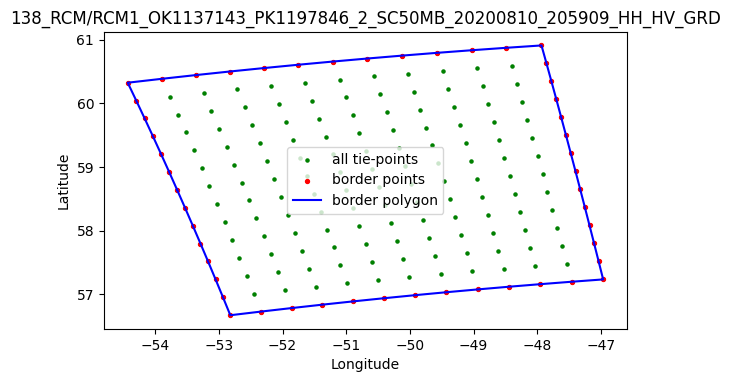

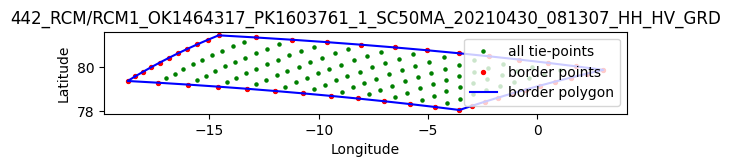


Folder: 118_RCM
{'order_folder': '118_RCM', 'scene_folder': 'RCM2_OK1045805_PK1061018_1_SC50MB_20200312_101035_HH_HV_GRD', 'footprint': <POLYGON ((-60.356 62.118, -60.437 61.836, -60.518 61.553, -60.598 61.27, -6...>}

Folder: 119_RCM
{'order_folder': '119_RCM', 'scene_folder': 'RCM1_OK1045805_PK1064079_4_SC50MB_20200320_100932_HH_HV_GRD', 'footprint': <POLYGON ((-62.124 54.99, -62.187 54.726, -62.249 54.462, -62.311 54.198, -6...>}

Folder: 120_RCM
{'order_folder': '120_RCM', 'scene_folder': 'RCM1_OK1061251_PK1073691_1_SC50MB_20200413_101024_HH_HV_GRD', 'footprint': <POLYGON ((-60.355 62.118, -60.437 61.836, -60.517 61.553, -60.597 61.27, -6...>}

Folder: 121_RCM
{'order_folder': '121_RCM', 'scene_folder': 'RCM1_OK1063157_PK1074745_3_SC50MB_20200416_103136_HH_HV_GRD', 'footprint': <POLYGON ((-66.288 62.461, -66.37 62.183, -66.45 61.904, -66.53 61.626, -66....>}

Folder: 122_RCM
{'order_folder': '122_RCM', 'scene_folder': 'RCM1_OK1061251_PK1074718_1_SC50MB_20200416_103136_HH_HV_GRD', 

In [16]:
"""
This code loops through downloaded RCM scenes to extract geolocation tie-points from their product.xml files.  
It identifies tie-points along the image borders and constructs a polygon representing the scene footprint.  
"""

# Calculate RCM polygons using tie-points from product.xml files
rcm_download_root = "./RCM"
rcm_polygons = []

for order_folder in os.listdir(rcm_download_root):
    order_path = os.path.join(rcm_download_root, order_folder)

    for scene_folder in os.listdir(order_path):
        scene_path = os.path.join(order_path, scene_folder)
        product_xml_path = os.path.join(scene_path, scene_folder, "metadata", "product.xml")
        if not os.path.exists(product_xml_path):
            continue                                    

        # parse all tie-points 
        tree = ET.parse(product_xml_path)
        root = tree.getroot()
        ns = {"ns": root.tag.split('}')[0].strip('{')}
        tie_pts = root.findall(".//ns:geolocationGrid/ns:imageTiePoint", namespaces=ns)
        lines, pixels, lats, lons = [], [], [], []
        for tp in tie_pts:
            img = tp.find("ns:imageCoordinate", namespaces=ns)
            geo = tp.find("ns:geodeticCoordinate", namespaces=ns)
            lines.append(float(img.find("ns:line",   namespaces=ns).text))
            pixels.append(float(img.find("ns:pixel", namespaces=ns).text))
            lats.append(float(geo.find("ns:latitude",  namespaces=ns).text))
            lons.append(float(geo.find("ns:longitude", namespaces=ns).text))

        # identify border tie-points 
        min_line, max_line = min(lines), max(lines)
        min_pix,  max_pix  = min(pixels), max(pixels)

        border_mask = [(ln in (min_line, max_line) or
                        px in (min_pix,  max_pix))
                       for ln, px in zip(lines, pixels)]
        border_pts = [(lon, lat) for lon, lat, is_b in
                      zip(lons, lats, border_mask) if is_b]

        if len(border_pts) < 3:                         
            continue

        cx = np.mean([p[0] for p in border_pts])
        cy = np.mean([p[1] for p in border_pts])
        border_pts_sorted = sorted( border_pts, key=lambda p: np.arctan2(p[1] - cy, p[0] - cx))

        footprint = Polygon(border_pts_sorted)
        rcm_polygons.append({
            "order_folder": order_folder,
            "scene_folder": scene_folder,
            "footprint": footprint
        })

        # plot
        plt.figure(figsize=(6, 6))
        plt.scatter(lons,  lats,  s=5,  c="green", label="all tie-points")
        plt.scatter(*zip(*border_pts), s=8, c="red", label="border points")
        x, y = footprint.exterior.xy
        plt.plot(x, y, color="blue", linewidth=1.5, label="border polygon")
        plt.gca().set_aspect("equal", "box")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.title(f"{order_folder}/{scene_folder}")
        plt.legend()
        plt.tight_layout()
        plt.show()

unique_folders = sorted({p["order_folder"] for p in rcm_polygons})
for folder in unique_folders:
    print(f"\nFolder: {folder}")
    for poly in rcm_polygons:
        if poly["order_folder"] == folder:
            print(poly)


Folder: 118  |  Sentinel file: S1A_EW_GRDM_1SDH_20200312T102631_20200312T102731_031641_03A5A3_E76A_icechart_cis_SGRDIEA_20200312T1024Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200312T102631_20200312T102731_031641_03A5A3_E76A_icechart_cis_SGRDIEA_20200312T1024Z_pl_a.nc
  Footprint: {'shapefile': '118_S1A_EW_GRDM_1SDH_20200312T102631_20200312T102731_031641_03A5A3_E76A_icechart_cis_SGRDIEA_20200312T1024Z_pl_a.zip', 'rcm_folder': '118_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200312T102631_20200312T102731_031641_03A5A3_E76A_icechart_cis_SGRDIEA_20200312T1024Z_pl_a.nc', 'footprint': <POLYGON ((-53.833 64.336, -54.249 64.389, -54.668 64.44, -55.087 64.49, -55...>}


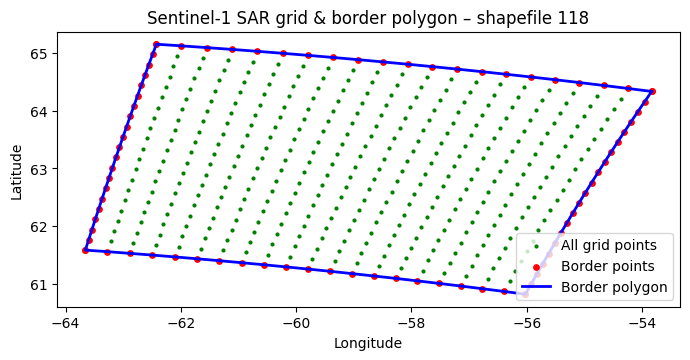


Folder: 119  |  Sentinel file: S1A_EW_GRDM_1SDH_20200319T102035_20200319T102058_031743_03A932_FB85_icechart_cis_SGRDINFLD_20200319T1021Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200319T102035_20200319T102058_031743_03A932_FB85_icechart_cis_SGRDINFLD_20200319T1021Z_pl_a.nc
  Footprint: {'shapefile': '119_S1A_EW_GRDM_1SDH_20200319T102035_20200319T102058_031743_03A932_FB85_icechart_cis_SGRDINFLD_20200319T1021Z_pl_a.zip', 'rcm_folder': '119_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200319T102035_20200319T102058_031743_03A932_FB85_icechart_cis_SGRDINFLD_20200319T1021Z_pl_a.nc', 'footprint': <POLYGON ((-56.227 56.279, -56.557 56.324, -56.887 56.368, -57.218 56.411, -...>}


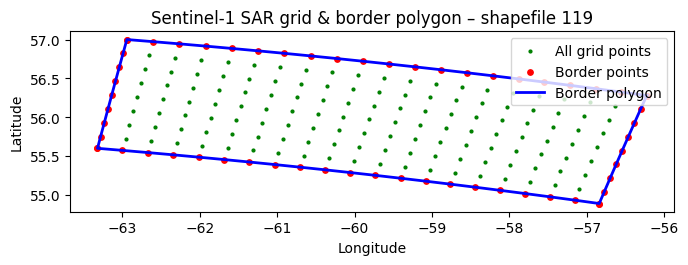


Folder: 120  |  Sentinel file: S1A_EW_GRDM_1SDH_20200412T101835_20200412T101935_032093_03B587_95D1_icechart_cis_SGRDIEA_20200412T1021Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200412T101835_20200412T101935_032093_03B587_95D1_icechart_cis_SGRDIEA_20200412T1021Z_pl_a.nc
  Footprint: {'shapefile': '120_S1A_EW_GRDM_1SDH_20200412T101835_20200412T101935_032093_03B587_95D1_icechart_cis_SGRDIEA_20200412T1021Z_pl_a.zip', 'rcm_folder': '120_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200412T101835_20200412T101935_032093_03B587_95D1_icechart_cis_SGRDIEA_20200412T1021Z_pl_a.nc', 'footprint': <POLYGON ((-52.407 63.349, -52.811 63.401, -53.216 63.451, -53.623 63.5, -54...>}


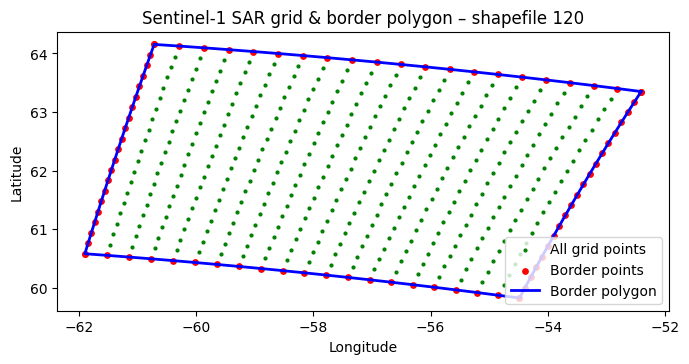


Folder: 121  |  Sentinel file: S1A_EW_GRDM_1SDH_20200415T104254_20200415T104354_032137_03B710_85E7_icechart_cis_SGRDINFLD_20200415T1033Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200415T104254_20200415T104354_032137_03B710_85E7_icechart_cis_SGRDINFLD_20200415T1033Z_pl_a.nc
  Footprint: {'shapefile': '121_S1A_EW_GRDM_1SDH_20200415T104254_20200415T104354_032137_03B710_85E7_icechart_cis_SGRDINFLD_20200415T1033Z_pl_a.zip', 'rcm_folder': '121_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200415T104254_20200415T104354_032137_03B710_85E7_icechart_cis_SGRDINFLD_20200415T1033Z_pl_a.nc', 'footprint': <POLYGON ((-57.73 64.647, -58.152 64.7, -58.575 64.752, -59 64.803, -59.427 ...>}


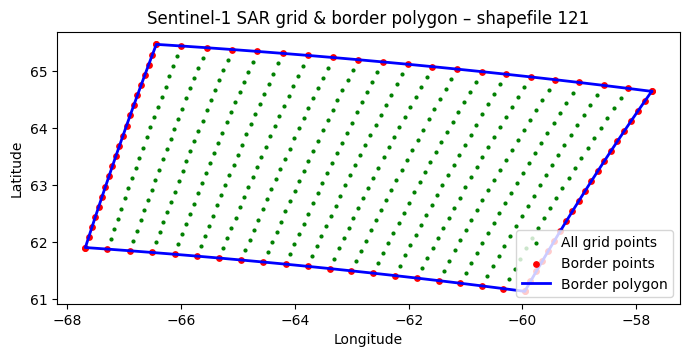


Folder: 122  |  Sentinel file: S1A_EW_GRDM_1SDH_20200415T104354_20200415T104457_032137_03B710_A752_icechart_cis_SGRDINFLD_20200415T1033Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200415T104354_20200415T104457_032137_03B710_A752_icechart_cis_SGRDINFLD_20200415T1033Z_pl_a.nc
  Footprint: {'shapefile': '122_S1A_EW_GRDM_1SDH_20200415T104354_20200415T104457_032137_03B710_A752_icechart_cis_SGRDINFLD_20200415T1033Z_pl_a.zip', 'rcm_folder': '122_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200415T104354_20200415T104457_032137_03B710_A752_icechart_cis_SGRDINFLD_20200415T1033Z_pl_a.nc', 'footprint': <POLYGON ((-59.96 61.131, -60.337 61.18, -60.715 61.228, -61.094 61.275, -61...>}


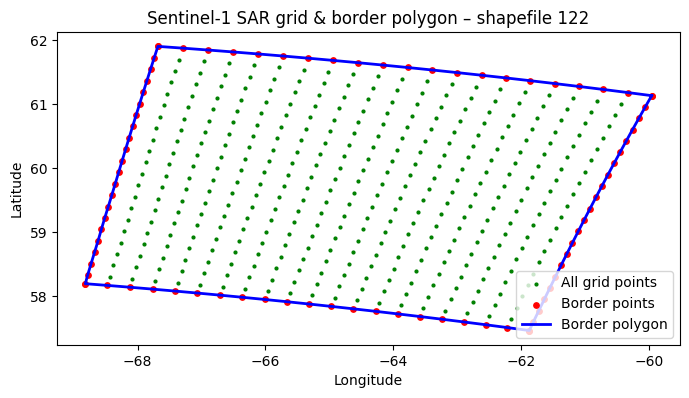


Folder: 123  |  Sentinel file: S1A_EW_GRDM_1SDH_20200424T101936_20200424T102036_032268_03BBA9_1CA8_icechart_cis_SGRDINFLD_20200424T1020Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200424T101936_20200424T102036_032268_03BBA9_1CA8_icechart_cis_SGRDINFLD_20200424T1020Z_pl_a.nc
  Footprint: {'shapefile': '123_S1A_EW_GRDM_1SDH_20200424T101936_20200424T102036_032268_03BBA9_1CA8_icechart_cis_SGRDINFLD_20200424T1020Z_pl_a.zip', 'rcm_folder': '123_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200424T101936_20200424T102036_032268_03BBA9_1CA8_icechart_cis_SGRDINFLD_20200424T1020Z_pl_a.nc', 'footprint': <POLYGON ((-54.485 59.825, -54.847 59.872, -55.211 59.919, -55.575 59.965, -...>}


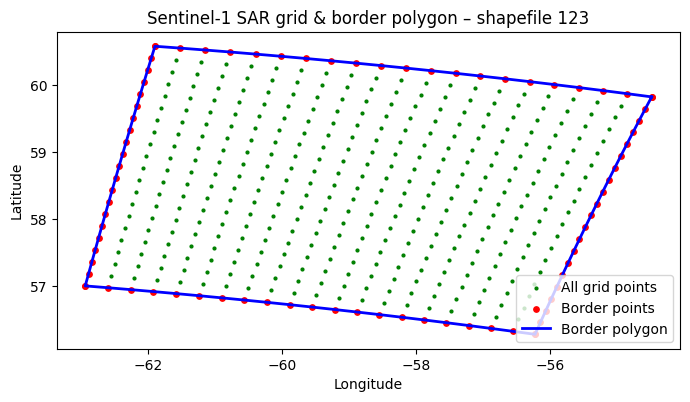


Folder: 124  |  Sentinel file: S1A_EW_GRDM_1SDH_20200424T102036_20200424T102059_032268_03BBA9_CB87_icechart_cis_SGRDINFLD_20200424T1020Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200424T102036_20200424T102059_032268_03BBA9_CB87_icechart_cis_SGRDINFLD_20200424T1020Z_pl_a.nc
  Footprint: {'shapefile': '124_S1A_EW_GRDM_1SDH_20200424T102036_20200424T102059_032268_03BBA9_CB87_icechart_cis_SGRDINFLD_20200424T1020Z_pl_a.zip', 'rcm_folder': '124_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200424T102036_20200424T102059_032268_03BBA9_CB87_icechart_cis_SGRDINFLD_20200424T1020Z_pl_a.nc', 'footprint': <POLYGON ((-56.227 56.279, -56.557 56.324, -56.887 56.368, -57.218 56.411, -...>}


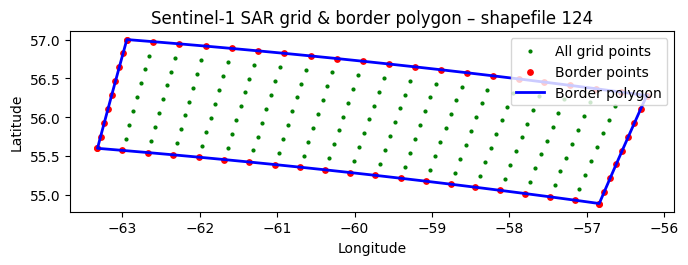


Folder: 125  |  Sentinel file: S1A_EW_GRDM_1SDH_20200505T205226_20200505T205331_032435_03C198_05FD_icechart_dmi_202005052050_CapeFarewell_RIC.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200505T205226_20200505T205331_032435_03C198_05FD_icechart_dmi_202005052050_CapeFarewell_RIC.nc
  Footprint: {'shapefile': '125_S1A_EW_GRDM_1SDH_20200505T205226_20200505T205331_032435_03C198_05FD_icechart_dmi_202005052050_CapeFarewell_RIC.zip', 'rcm_folder': '125_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200505T205226_20200505T205331_032435_03C198_05FD_icechart_dmi_202005052050_CapeFarewell_RIC.nc', 'footprint': <POLYGON ((-51.682 56.8, -51.35 56.845, -51.018 56.889, -50.684 56.932, -50....>}


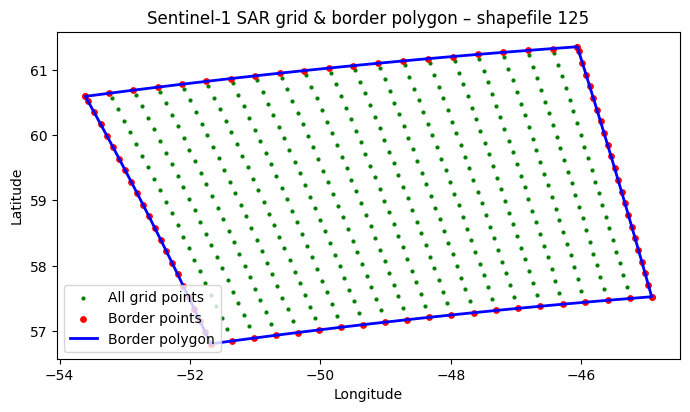


Folder: 126  |  Sentinel file: S1A_EW_GRDM_1SDH_20200506T101936_20200506T102036_032443_03C1D0_8286_icechart_cis_SGRDINFLD_20200506T1022Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200506T101936_20200506T102036_032443_03C1D0_8286_icechart_cis_SGRDINFLD_20200506T1022Z_pl_a.nc
  Footprint: {'shapefile': '126_S1A_EW_GRDM_1SDH_20200506T101936_20200506T102036_032443_03C1D0_8286_icechart_cis_SGRDINFLD_20200506T1022Z_pl_a.zip', 'rcm_folder': '126_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200506T101936_20200506T102036_032443_03C1D0_8286_icechart_cis_SGRDINFLD_20200506T1022Z_pl_a.nc', 'footprint': <POLYGON ((-54.486 59.825, -54.848 59.872, -55.212 59.919, -55.576 59.964, -...>}


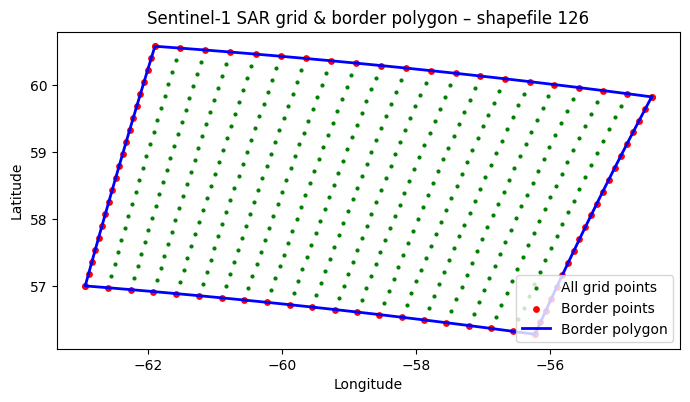


Folder: 127  |  Sentinel file: S1A_EW_GRDM_1SDH_20200506T102036_20200506T102100_032443_03C1D0_2B50_icechart_cis_SGRDINFLD_20200506T1022Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200506T102036_20200506T102100_032443_03C1D0_2B50_icechart_cis_SGRDINFLD_20200506T1022Z_pl_a.nc
  Footprint: {'shapefile': '127_S1A_EW_GRDM_1SDH_20200506T102036_20200506T102100_032443_03C1D0_2B50_icechart_cis_SGRDINFLD_20200506T1022Z_pl_a.zip', 'rcm_folder': '127_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200506T102036_20200506T102100_032443_03C1D0_2B50_icechart_cis_SGRDINFLD_20200506T1022Z_pl_a.nc', 'footprint': <POLYGON ((-56.228 56.279, -56.558 56.324, -56.888 56.368, -57.219 56.411, -...>}


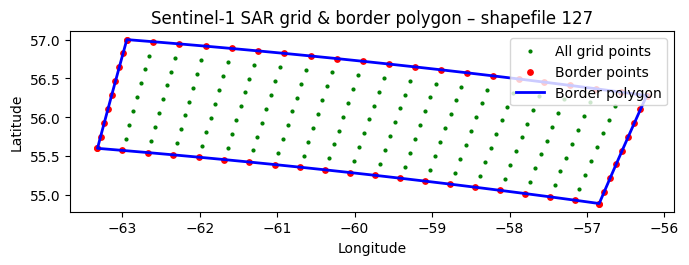


Folder: 128  |  Sentinel file: S1A_EW_GRDM_1SDH_20200514T104800_20200514T104904_032560_03C568_06DB_icechart_dmi_202005141050_NorthWest_RIC.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200514T104800_20200514T104904_032560_03C568_06DB_icechart_dmi_202005141050_NorthWest_RIC.nc
  Footprint: {'shapefile': '128_S1A_EW_GRDM_1SDH_20200514T104800_20200514T104904_032560_03C568_06DB_icechart_dmi_202005141050_NorthWest_RIC.zip', 'rcm_folder': '128_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200514T104800_20200514T104904_032560_03C568_06DB_icechart_dmi_202005141050_NorthWest_RIC.nc', 'footprint': <POLYGON ((-47.408 75.444, -48.093 75.529, -48.783 75.61, -49.478 75.69, -50...>}


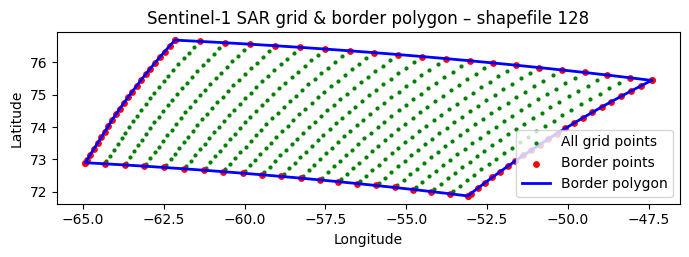


Folder: 129  |  Sentinel file: S1A_EW_GRDM_1SDH_20200523T102734_20200523T102836_032691_03C95E_376A_icechart_cis_SGRDIEA_20200523T1026Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200523T102734_20200523T102836_032691_03C95E_376A_icechart_cis_SGRDIEA_20200523T1026Z_pl_a.nc
  Footprint: {'shapefile': '129_S1A_EW_GRDM_1SDH_20200523T102734_20200523T102836_032691_03C95E_376A_icechart_cis_SGRDIEA_20200523T1026Z_pl_a.zip', 'rcm_folder': '129_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200523T102734_20200523T102836_032691_03C95E_376A_icechart_cis_SGRDIEA_20200523T1026Z_pl_a.nc', 'footprint': <POLYGON ((-56.025 60.818, -56.397 60.867, -56.771 60.914, -57.146 60.961, -...>}


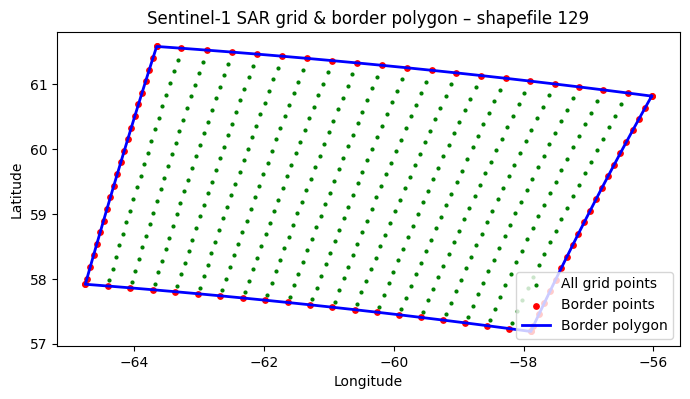


Folder: 130  |  Sentinel file: S1A_EW_GRDM_1SDH_20200619T122818_20200619T122923_033086_03D537_EA36_icechart_cis_SGRDIFOXE_20200619T1216Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200619T122818_20200619T122923_033086_03D537_EA36_icechart_cis_SGRDIFOXE_20200619T1216Z_pl_a.nc
  Footprint: {'shapefile': '130_S1A_EW_GRDM_1SDH_20200619T122818_20200619T122923_033086_03D537_EA36_icechart_cis_SGRDIFOXE_20200619T1216Z_pl_a.zip', 'rcm_folder': '130_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200619T122818_20200619T122923_033086_03D537_EA36_icechart_cis_SGRDIFOXE_20200619T1216Z_pl_a.nc', 'footprint': <POLYGON ((-79.466 70.311, -79.993 70.376, -80.523 70.439, -81.057 70.5, -81...>}


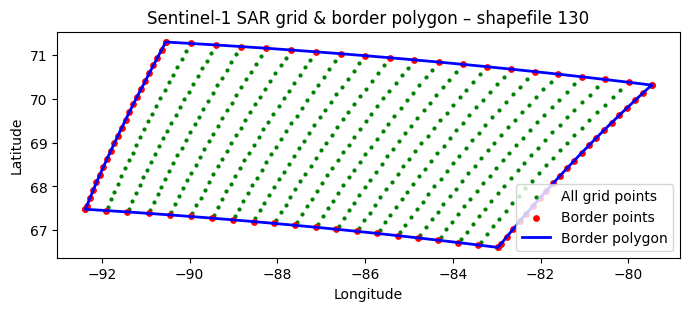


Folder: 131  |  Sentinel file: S1A_EW_GRDM_1SDH_20200625T081801_20200625T081905_033171_03D7BC_C1A2_icechart_dmi_202006250820_CentralEast_RIC.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200625T081801_20200625T081905_033171_03D7BC_C1A2_icechart_dmi_202006250820_CentralEast_RIC.nc
  Footprint: {'shapefile': '131_S1A_EW_GRDM_1SDH_20200625T081801_20200625T081905_033171_03D7BC_C1A2_icechart_dmi_202006250820_CentralEast_RIC.zip', 'rcm_folder': '131_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200625T081801_20200625T081905_033171_03D7BC_C1A2_icechart_dmi_202006250820_CentralEast_RIC.nc', 'footprint': <POLYGON ((9.922 81.158, 9.046 81.291, 8.143 81.421, 7.213 81.549, 6.255 81....>}


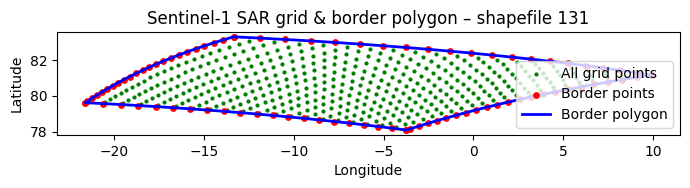


Folder: 132  |  Sentinel file: S1A_EW_GRDM_1SDH_20200626T104258_20200626T104358_033187_03D833_60CD_icechart_cis_SGRDIEA_20200626T1033Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200626T104258_20200626T104358_033187_03D833_60CD_icechart_cis_SGRDIEA_20200626T1033Z_pl_a.nc
  Footprint: {'shapefile': '132_S1A_EW_GRDM_1SDH_20200626T104258_20200626T104358_033187_03D833_60CD_icechart_cis_SGRDIEA_20200626T1033Z_pl_a.zip', 'rcm_folder': '132_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200626T104258_20200626T104358_033187_03D833_60CD_icechart_cis_SGRDIEA_20200626T1033Z_pl_a.nc', 'footprint': <POLYGON ((-57.731 64.647, -58.152 64.7, -58.576 64.752, -59.001 64.803, -59...>}


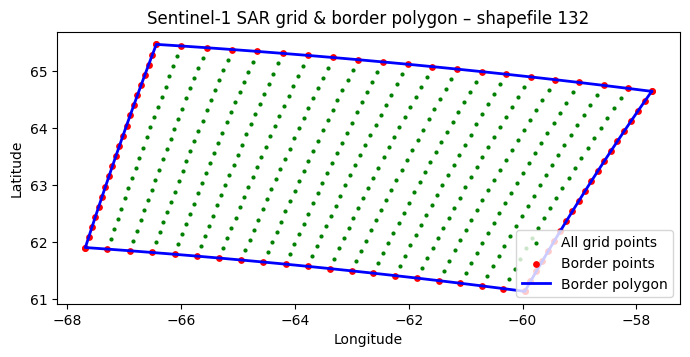


Folder: 133  |  Sentinel file: S1A_EW_GRDM_1SDH_20200704T111639_20200704T111741_033304_03DBCC_0A36_icechart_cis_SGRDIFOXE_20200704T1116Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200704T111639_20200704T111741_033304_03DBCC_0A36_icechart_cis_SGRDIFOXE_20200704T1116Z_pl_a.nc
  Footprint: {'shapefile': '133_S1A_EW_GRDM_1SDH_20200704T111639_20200704T111741_033304_03DBCC_0A36_icechart_cis_SGRDIFOXE_20200704T1116Z_pl_a.zip', 'rcm_folder': '133_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200704T111639_20200704T111741_033304_03DBCC_0A36_icechart_cis_SGRDIFOXE_20200704T1116Z_pl_a.nc', 'footprint': <POLYGON ((-67.675 62.01, -68.063 62.06, -68.452 62.108, -68.842 62.156, -69...>}


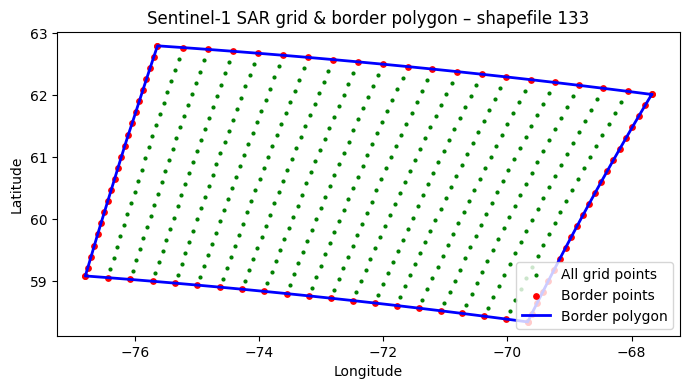


Folder: 134  |  Sentinel file: S1A_EW_GRDM_1SDH_20200706T203552_20200706T203656_033339_03DCD6_6D55_icechart_dmi_202007062030_CapeFarewell_RIC.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200706T203552_20200706T203656_033339_03DCD6_6D55_icechart_dmi_202007062030_CapeFarewell_RIC.nc
  Footprint: {'shapefile': '134_S1A_EW_GRDM_1SDH_20200706T203552_20200706T203656_033339_03DCD6_6D55_icechart_dmi_202007062030_CapeFarewell_RIC.zip', 'rcm_folder': '134_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200706T203552_20200706T203656_033339_03DCD6_6D55_icechart_dmi_202007062030_CapeFarewell_RIC.nc', 'footprint': <POLYGON ((-47.283 56.154, -46.957 56.198, -46.631 56.241, -46.304 56.284, -...>}


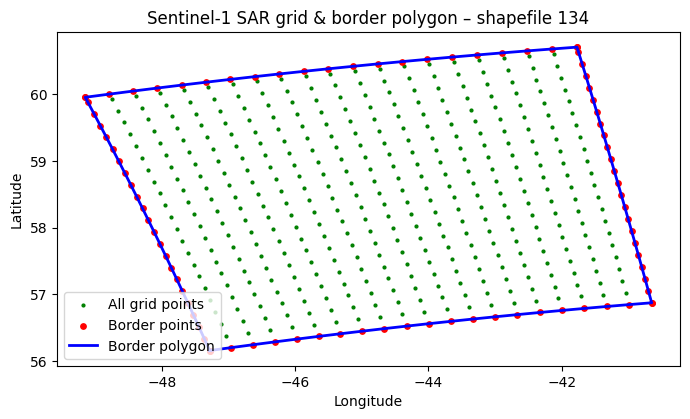


Folder: 135  |  Sentinel file: S1A_EW_GRDM_1SDH_20200716T111235_20200716T111339_033479_03E124_A23A_icechart_dmi_202007161110_Qaanaaq_RIC.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200716T111235_20200716T111339_033479_03E124_A23A_icechart_dmi_202007161110_Qaanaaq_RIC.nc
  Footprint: {'shapefile': '135_S1A_EW_GRDM_1SDH_20200716T111235_20200716T111339_033479_03E124_A23A_icechart_dmi_202007161110_Qaanaaq_RIC.zip', 'rcm_folder': '135_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200716T111235_20200716T111339_033479_03E124_A23A_icechart_dmi_202007161110_Qaanaaq_RIC.nc', 'footprint': <POLYGON ((-52.448 75.968, -53.15 76.055, -53.859 76.139, -54.574 76.221, -5...>}


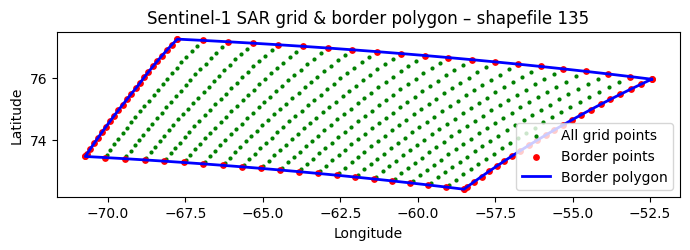


Folder: 136  |  Sentinel file: S1A_EW_GRDM_1SDH_20200730T203553_20200730T203658_033689_03E790_EC41_icechart_dmi_202007302035_CapeFarewell_RIC.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200730T203553_20200730T203658_033689_03E790_EC41_icechart_dmi_202007302035_CapeFarewell_RIC.nc
  Footprint: {'shapefile': '136_S1A_EW_GRDM_1SDH_20200730T203553_20200730T203658_033689_03E790_EC41_icechart_dmi_202007302035_CapeFarewell_RIC.zip', 'rcm_folder': '136_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200730T203553_20200730T203658_033689_03E790_EC41_icechart_dmi_202007302035_CapeFarewell_RIC.nc', 'footprint': <POLYGON ((-47.285 56.155, -46.96 56.199, -46.633 56.242, -46.307 56.285, -4...>}


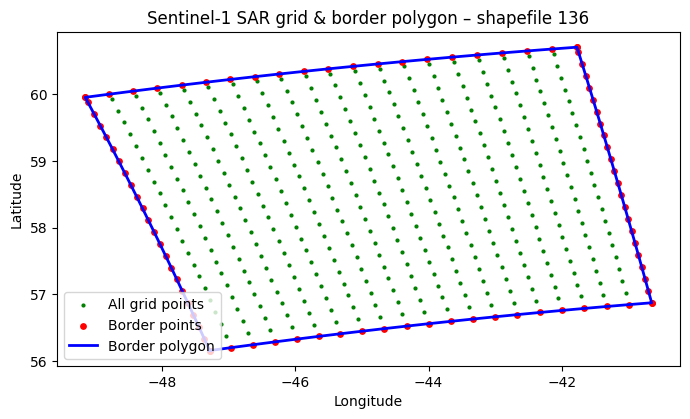


Folder: 138  |  Sentinel file: S1A_EW_GRDM_1SDH_20200809T205232_20200809T205336_033835_03EC5F_50FC_icechart_dmi_202008092055_CapeFarewell_RIC.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200809T205232_20200809T205336_033835_03EC5F_50FC_icechart_dmi_202008092055_CapeFarewell_RIC.nc
  Footprint: {'shapefile': '138_S1A_EW_GRDM_1SDH_20200809T205232_20200809T205336_033835_03EC5F_50FC_icechart_dmi_202008092055_CapeFarewell_RIC.zip', 'rcm_folder': '138_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200809T205232_20200809T205336_033835_03EC5F_50FC_icechart_dmi_202008092055_CapeFarewell_RIC.nc', 'footprint': <POLYGON ((-51.685 56.8, -51.352 56.845, -51.018 56.888, -50.684 56.932, -50...>}


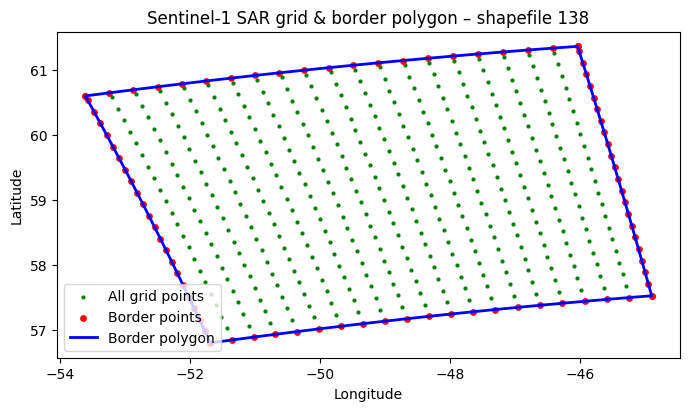


Folder: 442  |  Sentinel file: S1B_EW_GRDM_1SDH_20210429T080105_20210429T080205_026679_032FAF_A971_icechart_dmi_202104290800_North_RIC.nc
  Sentinel: S1B_EW_GRDM_1SDH_20210429T080105_20210429T080205_026679_032FAF_A971_icechart_dmi_202104290800_North_RIC.nc
  Footprint: {'shapefile': '442_S1B_EW_GRDM_1SDH_20210429T080105_20210429T080205_026679_032FAF_A971_icechart_dmi_202104290800_North_RIC.zip', 'rcm_folder': '442_RCM', 'base_name': 'S1B_EW_GRDM_1SDH_20210429T080105_20210429T080205_026679_032FAF_A971_icechart_dmi_202104290800_North_RIC.nc', 'footprint': <POLYGON ((11.262 80.704, 10.392 80.83, 9.498 80.954, 8.58 81.076, 7.637 81....>}


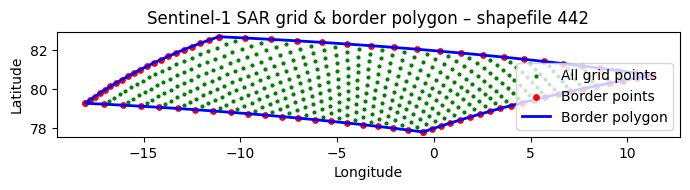

In [17]:
"""
This code matches Sentinel-1 shapefiles to their corresponding NetCDF (.nc) files and extracts valid SAR grid latitude/longitude points.  
It identifies the outer border points of each scene to calculate a polygon representing the Sentinel-1 footprint.  
The resulting footprint is visualized and stored for later comparison with RCM scenes.
"""
sentinel1_data_folder = "./train_dataset"
shapefile_folder      = "./train_dataset_shapefiles"
rcm_download_root     = "./RCM"

sentinel_footprints = []
available_rcm_folders = {
    f.split("_")[0]
    for f in os.listdir(rcm_download_root)
    if os.path.isdir(os.path.join(rcm_download_root, f)) and f.endswith("_RCM")
}


for shapefile_zip in os.listdir(shapefile_folder):
    match = re.match(r"(\d+)_([^.]+)\.zip", shapefile_zip)
    if not match:
        continue                       
    shapefile_number = match.group(1)  
    shapefile_base   = match.group(2) 
    if shapefile_number not in available_rcm_folders:
        continue

    matched_nc = None
    for nc_file in os.listdir(sentinel1_data_folder):
        if nc_file.endswith(".nc") and shapefile_base in nc_file:
            matched_nc = os.path.join(sentinel1_data_folder, nc_file)
            break
    if matched_nc is None:
        print(f"No matching .nc found for {shapefile_zip}")
        continue

    print(f"\nFolder: {shapefile_number}  |  Sentinel file: {os.path.basename(matched_nc)}")

    ds = xr.open_dataset(matched_nc)
    lat = ds['sar_grid_latitude'].values
    lon = ds['sar_grid_longitude'].values
    line = ds['sar_grid_line'].values      
    sample = ds['sar_grid_sample'].values  

    valid = np.isfinite(lat) & np.isfinite(lon)
    lat, lon, line, sample = lat[valid], lon[valid], line[valid], sample[valid]

    top_mask = line   == line.min()
    bottom_mask = line   == line.max()
    left_mask = sample == sample.min()
    right_mask = sample == sample.max()

    top_idx = np.argsort(sample[top_mask])             # left -> right
    right_idx = np.argsort(line[right_mask])             # top  -> bottom
    bottom_idx = np.argsort(sample[bottom_mask])[::-1]    # right -> left
    left_idx = np.argsort(line[left_mask])[::-1]        # bottom -> top

    border_lats = np.concatenate([
        lat[top_mask][top_idx],
        lat[right_mask][right_idx],
        lat[bottom_mask][bottom_idx],
        lat[left_mask][left_idx]
    ])
    border_lons = np.concatenate([
        lon[top_mask][top_idx],
        lon[right_mask][right_idx],
        lon[bottom_mask][bottom_idx],
        lon[left_mask][left_idx]
    ])

    sentinel_polygon = Polygon(zip(border_lons, border_lats))
    matching_rcm_folder = next(f for f in available_rcm_folders if f == shapefile_number)

    sentinel_footprints.append({
        'shapefile': shapefile_zip,
        'rcm_folder': f"{matching_rcm_folder}_RCM",
        'base_name': os.path.basename(matched_nc),
        'footprint': sentinel_polygon})

    print(f"  Sentinel: {os.path.basename(matched_nc)}")
    print(f"  Footprint: {sentinel_footprints[-1]}") 

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(lon, lat, s=4,  color='green', label='All grid points')
    ax.scatter(border_lons, border_lats, s=15, color='red',   label='Border points')
    poly_x, poly_y = sentinel_polygon.exterior.xy
    ax.plot(poly_x, poly_y, color='blue', linewidth=2, label='Border polygon')
    ax.set_aspect('equal')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title(f"Sentinel-1 SAR grid & border polygon – shapefile {shapefile_number}")
    ax.legend(loc='best'); plt.tight_layout(); plt.show()

In [18]:
"""
This code compares each Sentinel-1 footprint with RCM scene polygons to calculate their spatial overlap.  
It selects the RCM scene with the highest intersection area for each Sentinel-1 file and records the overlap percentages.  
"""
best_RCM_match = []
all_overlaps = [] 

# calculate overlaps between Sentinel-1 and RCM scenes
for sentinel_scene in sentinel_footprints:
    sentinel_footprint = sentinel_scene['footprint']
    sentinel_name = sentinel_scene['shapefile']
    sentinel_clean_name = re.sub(r'^\d+_', '', sentinel_name)

    overlaps = []

    for rcm_scene in rcm_polygons:
        if rcm_scene['order_folder'] != sentinel_scene['rcm_folder']:
            continue

        rcm_polygon = rcm_scene['footprint']

        intersection_area = rcm_polygon.intersection(sentinel_footprint).area
        rcm_area = rcm_polygon.area
        sentinel_area = sentinel_footprint.area

        row = {
            'sentinel_shape_file': sentinel_name,
            'sentinel_file': sentinel_clean_name,
            'rcm_folder': rcm_scene['order_folder'],
            'rcm_scene': rcm_scene['scene_folder'],
            'overlap_area': intersection_area,
            'overlap_percent_rcm': (intersection_area / rcm_area) * 100,
            'overlap_percent_sentinel': (intersection_area / sentinel_area) * 100
        }
        overlaps.append(row)
        all_overlaps.append(row)

    overlaps_sorted = sorted(overlaps, key=lambda x: x['overlap_area'], reverse=True)
    print(overlaps_sorted)
    if overlaps_sorted:
        best_match = overlaps_sorted[:1]
        print(f"\nBest RCM match for Sentinel-1: {sentinel_name}")
        for i, match in enumerate(best_match, 1):
            print(f"\n    RCM Scene: {match['rcm_folder']}/{match['rcm_scene']}")
            print(f"    Overlap Area: {match['overlap_area']:.4f}")
            print(f"    Overlap % of RCM: {match['overlap_percent_rcm']:.2f}%")
            print(f"    Overlap % of Sentinel-1: {match['overlap_percent_sentinel']:.2f}%")
            best_path = os.path.join(rcm_download_root, match['rcm_folder'], match['rcm_scene'],match['rcm_scene'])
            best_RCM_match.append(best_path)

print("\n", best_RCM_match)
# pd.DataFrame(all_overlaps).to_excel("s1_rcm_overlap.xlsx", index=False)


[{'sentinel_shape_file': '118_S1A_EW_GRDM_1SDH_20200312T102631_20200312T102731_031641_03A5A3_E76A_icechart_cis_SGRDIEA_20200312T1024Z_pl_a.zip', 'sentinel_file': 'S1A_EW_GRDM_1SDH_20200312T102631_20200312T102731_031641_03A5A3_E76A_icechart_cis_SGRDIEA_20200312T1024Z_pl_a.zip', 'rcm_folder': '118_RCM', 'rcm_scene': 'RCM2_OK1045805_PK1061018_1_SC50MB_20200312_101035_HH_HV_GRD', 'overlap_area': 16.26795558227694, 'overlap_percent_rcm': 62.44998886647617, 'overlap_percent_sentinel': 53.9979242285812}]

Best RCM match for Sentinel-1: 118_S1A_EW_GRDM_1SDH_20200312T102631_20200312T102731_031641_03A5A3_E76A_icechart_cis_SGRDIEA_20200312T1024Z_pl_a.zip

    RCM Scene: 118_RCM/RCM2_OK1045805_PK1061018_1_SC50MB_20200312_101035_HH_HV_GRD
    Overlap Area: 16.2680
    Overlap % of RCM: 62.45%
    Overlap % of Sentinel-1: 54.00%
[{'sentinel_shape_file': '119_S1A_EW_GRDM_1SDH_20200319T102035_20200319T102058_031743_03A932_FB85_icechart_cis_SGRDINFLD_20200319T1021Z_pl_a.zip', 'sentinel_file': 'S1A_EW_G

Calibration into Sigma nought

In [8]:
# converting Tif images to float32, replace 0 values with NaN
rcm_root = "./RCM"
for folder_path in best_RCM_match:
    folder_name = os.path.basename(folder_path)        
    order_folder = os.path.basename(os.path.dirname(folder_path))
    folder_root = folder_path
    imagery_path = os.path.join(folder_root, 'imagery')
    if not os.path.isdir(imagery_path):
        print(f"Skipping: {imagery_path} (not found)")
        continue
    print(f"\nProcessing: {imagery_path}")

    for tif_file in os.listdir(imagery_path):
        if not tif_file.endswith(".tif"):
            continue
        tif_path = os.path.join(imagery_path, tif_file)

        with rasterio.open(tif_path) as src:
            arr = src.read(1).astype(np.float32)  # convert to float32
            profile = src.profile.copy()

        arr[arr == 0] = np.nan                   # replace 0s with NaN
        profile.update(dtype='float32', nodata=np.nan)  # update metadata

        base, ext = os.path.splitext(tif_file)
        new_filename = f"{base}_nan.tif"
        new_path = os.path.join(imagery_path, new_filename)

        # save
        with rasterio.open(new_path, 'w', **profile) as dst:
            dst.write(arr, 1)

        print(f"Saved: {new_filename}")


Processing: ./RCM\442_RCM\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD\imagery


c:\Users\Niloo\AppData\Local\Programs\Python\Python311\Lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


Saved: 1603761_1_HH_nan.tif
Saved: 1603761_1_HV_nan.tif


In [9]:
"""
This code performs radiometric calibration of RCM HH and HV TIFF images into Sigma⁰ (σ⁰) backscatter in decibels using look-up tables (LUTs) from XML metadata.  
It reads the digital number (DN) values, applies calibration gains through interpolation, converts to dB scale, and prints summary statistics for each polarization.  
"""
def calibrate_sigma0(tiff_path, lut_path):
    with rasterio.open(tiff_path) as src:
        dn = src.read(1).astype(np.float32)
        tags = src.tags()
        profile = src.profile
        if src.nodata is not None:
            dn = np.ma.masked_equal(dn, src.nodata)
    tree = ET.parse(lut_path)
    root = tree.getroot()
    ns = {'ns': root.tag.split('}')[0].strip('{')}
    gains_elem = root.find("ns:gains", ns)
    gains_text = gains_elem.text.strip()
    gains = np.array(list(map(float, gains_text.split())))
    step_size_elem = root.find("ns:stepSize", ns)
    step_size = int(step_size_elem.text.strip())
    height, width = dn.shape
    num_values = len(gains)
    
    if step_size < 0:
        start_row = int(root.find("ns:pixelFirstLutValue", ns).text.strip())
        lut_rows = np.arange(start_row, start_row + step_size * num_values, step_size)
        gains = gains[::-1]
    else:
        lut_rows = np.arange(0, height, step_size)
    lut_rows = lut_rows[:len(gains)]
    interp_func = interp1d(lut_rows, gains[:len(lut_rows)], kind='linear', fill_value='extrapolate')
    gains_full = interp_func(np.arange(height))
    lut_2d = np.tile(gains_full[:, np.newaxis], (1, width))
    sigma0_linear = (dn ** 2) / lut_2d
    sigma0_dB = 10 * np.log10(sigma0_linear + 1e-10)
    return sigma0_dB, profile, tags
 
 
for folder_path in best_RCM_match:
    folder_name = os.path.basename(folder_path)        
    order_folder = os.path.basename(os.path.dirname(folder_path))
    folder_root = folder_path
    imagery_path = os.path.join(folder_root, 'imagery')
    calibration_path = os.path.join(folder_root, 'metadata', 'calibration')
    hh_files = [f for f in os.listdir(imagery_path) if 'HH' in f and f.endswith('_HH_nan.tif')]
    print(hh_files)
    hv_files = [f for f in os.listdir(imagery_path) if 'HV' in f and f.endswith('_HV_nan.tif')]
    print(hv_files)
    hh_path = os.path.join(imagery_path, hh_files[0])
    hv_path = os.path.join(imagery_path, hv_files[0])
    lut_hh_path = os.path.join(calibration_path, "lutSigma_HH.xml")
    lut_hv_path = os.path.join(calibration_path, "lutSigma_HV.xml")
 
    # Calibrate HH, HV
    sigma0_dB_HH, profile_HH, tags_HH = calibrate_sigma0(hh_path, lut_hh_path)
    sigma0_dB_HV, profile_HV, tags_HV = calibrate_sigma0(hv_path, lut_hv_path)
 
    print(f"\n[HH] {folder_name}")
    print(f" - Min: {sigma0_dB_HH.min():.2f} dB")
    print(f" - Max: {sigma0_dB_HH.max():.2f} dB")
    print(f" - Mean: {sigma0_dB_HH.mean():.2f} dB")
    print(f"\n[HV] {folder_name}")
    print(f" - Min: {sigma0_dB_HV.min():.2f} dB")
    print(f" - Max: {sigma0_dB_HV.max():.2f} dB")
    print(f" - Mean: {sigma0_dB_HV.mean():.2f} dB")

    calibrated_dir = os.path.join(folder_root, 'calibrated_imagery')
    os.makedirs(calibrated_dir, exist_ok=True)
    # Save HH
    profile_HH.update(dtype='float32', count=1, compress='lzw')
    save_path_HH = os.path.join(calibrated_dir, f"{folder_name}_nan_sigma0_HH_dB.tif")
    with rasterio.open(save_path_HH, 'w', **profile_HH) as dst:
        dst.write(sigma0_dB_HH.astype(np.float32), 1)
        dst.update_tags(**tags_HH)
    # Save HV
    profile_HV.update(dtype='float32', count=1, compress='lzw')
    save_path_HV = os.path.join(calibrated_dir, f"{folder_name}_nan_sigma0_HV_dB.tif")
    with rasterio.open(save_path_HV, 'w', **profile_HV) as dst:
        dst.write(sigma0_dB_HV.astype(np.float32), 1)
        dst.update_tags(**tags_HV)

    # # Plot calibrated images
    # fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    # im1 = axs[0].imshow(sigma0_dB_HH, cmap='gray', vmin=-30, vmax=0)
    # axs[0].set_title(f"Calibrated HH - {order_folder}")
    # axs[0].axis('off')
    # fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04, label='σ⁰ (dB)')
    # im2 = axs[1].imshow(sigma0_dB_HV, cmap='gray', vmin=-30, vmax=0)
    # axs[1].set_title(f"Calibrated HV - {order_folder}")
    # axs[1].axis('off')
    # fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04, label='σ⁰ (dB)')
    # plt.suptitle(f"Radiometrically Calibrated RCM σ⁰ Images - {order_folder}/{folder_name}", fontsize=14)
    # plt.tight_layout()
    # plt.show()

['1603761_1_HH_nan.tif']
['1603761_1_HV_nan.tif']

[HH] RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD
 - Min: -42.91 dB
 - Max: 11.56 dB
 - Mean: -12.68 dB

[HV] RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD
 - Min: -53.53 dB
 - Max: 9.97 dB
 - Mean: -25.02 dB


Create Sentinel-1 Non-overlapping Area Mask

In [10]:
# create the sentinel_mask_dir in each RCM folder
for rcm_path in best_RCM_match:
    parts = os.path.normpath(rcm_path).split(os.sep)
    rcm_folder = parts[-3] 
    rcm_scene = parts[-2]  
    scene_base = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
    sentinel_mask_dir = os.path.join(scene_base,rcm_scene, "sentinel_mask")
    os.makedirs(sentinel_mask_dir, exist_ok=True)

Coregistering RCM and Sentinel-1 & Cropping the RCM image based on the S1 shapefile

In [12]:
# Extract RCM sparse geolocation tie points (line, pixel) to geographic (lat, lon) from product.xml
def parse_rcm_tie_points(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    ns = {'ns': root.tag.split('}')[0].strip('{')}
    lines, pixels, lats, lons = [], [], [], []
    for tp in root.findall(".//ns:geolocationGrid/ns:imageTiePoint", namespaces=ns):
        img = tp.find("ns:imageCoordinate", namespaces=ns)
        geo = tp.find("ns:geodeticCoordinate", namespaces=ns)
        lines.append(float(img.find("ns:line",   namespaces=ns).text))
        pixels.append(float(img.find("ns:pixel", namespaces=ns).text))
        lats.append(float(geo.find("ns:latitude",  namespaces=ns).text))
        lons.append(float(geo.find("ns:longitude", namespaces=ns).text))
    return np.array(lines), np.array(pixels), np.array(lats), np.array(lons)


# Load S1 NetCDF and interpolate lat/lon to every pixel of the full S1 image grid
matched_rcm_set     = {os.path.normpath(p).split(os.sep)[-3] for p in best_RCM_match}
matched_rcm_folders = sorted(matched_rcm_set, key=lambda f: int(f.split('_')[0]))
print(matched_rcm_folders)
for sentinel_scene in sentinel_footprints:
    print(sentinel_scene)
    rcm_folder = sentinel_scene['rcm_folder']
    if rcm_folder not in matched_rcm_folders:
        continue
    sentinel_nc_path = os.path.join("./train_dataset", sentinel_scene['base_name'])
    # sentinel_nc_path = os.path.join("./test_dataset", sentinel_scene['base_name'])

    print(f"Using .nc file: {sentinel_nc_path}")
    ds          = Dataset(sentinel_nc_path, "r")
    s1_data     = ds.variables["nersc_sar_primary"][:]
    rows_s1, cols_s1 = s1_data.shape
    lines_s1    = ds.variables["sar_grid_line"][:]
    samples_s1  = ds.variables["sar_grid_sample"][:]
    lats_s1     = ds.variables["sar_grid_latitude"][:]
    lons_s1     = ds.variables["sar_grid_longitude"][:]
    ds.close()
    s1_grid_row, s1_grid_col = np.meshgrid(np.arange(rows_s1), np.arange(cols_s1), indexing='ij')
    points_s1 = np.column_stack((lines_s1, samples_s1))
    s1_pixel_coords = np.column_stack((s1_grid_row.ravel(), s1_grid_col.ravel()))
    lat_s1_grid = griddata(points_s1, lats_s1, s1_pixel_coords, method='cubic').reshape(rows_s1, cols_s1)
    lon_s1_grid = griddata(points_s1, lons_s1, s1_pixel_coords, method='cubic').reshape(rows_s1, cols_s1)

    # Interpolate S1 lat/lon to RCM pixel locations
    # Resample RCM image onto Sentinel-1 pixel grid and attach GCPs
    order_path = os.path.join("./RCM", rcm_folder)
    for scene_folder in os.listdir(order_path):
        scene_path = os.path.join(order_path, scene_folder, scene_folder)

        
        '''
        interpolation functions that map geographic coordinates (lat, lon) back to RCM image pixel coordinates.  
        This inverse mapping lets us find, for each pixel in the S1 grid (with known lat/lon), the corresponding location in the RCM image.  
        '''
        rcm_xml_path = os.path.join(scene_path, "metadata", "product.xml")
        print(rcm_xml_path)
        lines_rcm, pixels_rcm, lats_rcm, lons_rcm = parse_rcm_tie_points(rcm_xml_path)
        print(f"  pairing S1 = {sentinel_nc_path}  ↔  RCM = {order_path}")
        points_rcm_geo = np.column_stack((lats_rcm, lons_rcm))
        latlon_coords  = np.column_stack((lat_s1_grid.ravel(), lon_s1_grid.ravel()))
        rcm_row_map    = griddata(points_rcm_geo, lines_rcm,   latlon_coords,  method='cubic').reshape(rows_s1, cols_s1)
        rcm_col_map    = griddata(points_rcm_geo, pixels_rcm,  latlon_coords,  method='cubic').reshape(rows_s1, cols_s1) 


        '''
        With the coordinate maps (`rcm_row_map`, `rcm_col_map`), we use `map_coordinates` to resample the original RCM image to the S1 pixel grid.  
        We then prepare Ground Control Points (GCPs) from the Sentinel-1 sparse grid, which contain georeferencing info (pixel to lat/lon).  
        Finally, we save the resampled RCM image **directly with the GCPs attached** to enable georeferencing without intermediate files.
        '''
        imagery_path = os.path.join(scene_path, "calibrated_imagery")

        if not os.path.isdir(imagery_path):
            continue

        for tif_name in os.listdir(imagery_path):
            if not tif_name.lower().endswith(".tif"):
                continue
            rcm_raster_path = os.path.join(imagery_path, tif_name)
            with rasterio.open(rcm_raster_path) as rcm_src:
                rcm_data    = rcm_src.read(1)
                rcm_profile = rcm_src.profile

            # Resample RCM data to Sentinel-1 grid coordinates (assumes rcm_row_map, rcm_col_map, rows_s1, cols_s1 are ready)
            coords    = np.vstack([rcm_row_map.ravel(), rcm_col_map.ravel()])
            resampled = map_coordinates(rcm_data, coords, order=1, mode='nearest').reshape(rows_s1, cols_s1)
            print("Checking NaNs in resampled image:")
            print(f"  Contains NaNs: {np.isnan(resampled).any()}")

            # Prepare GCPs from Sentinel-1 sparse grid
            gcps = []
            for line, sample, lat, lon in zip(
                lines_s1, samples_s1, lats_s1, lons_s1
            ):
                row = int(round(line))
                col = int(round(sample))
                if 0 <= row < rows_s1 and 0 <= col < cols_s1:
                    gcps.append(
                        GroundControlPoint(row=row, col=col, x=lon, y=lat)
                    )

            # Update profile for new resampled image
            profile = rcm_profile.copy()
            profile.update({
                "height": rows_s1,
                "width":  cols_s1,
                "dtype":  resampled.dtype,
                "count":  1,
            })
            profile.pop('nodata', None)

            out_path = os.path.join(
                imagery_path,
                f"{os.path.splitext(tif_name)[0]}_resampled_to_s1_grid_gcps.tif"
            )
            print(f"{out_path}  →  shape: {resampled.shape}")

            # Write resampled RCM image directly with GCPs
            with rasterio.open(out_path, "w", **profile) as dst:
                dst.write(resampled, 1)
                dst.gcps = (gcps, CRS.from_epsg(4326))

            print(f"Resampled RCM image saved with GCPs: {out_path}")

            # Create and save binary valid-pixel mask
            with rasterio.open(out_path) as src:
                img = src.read(1)
                profile = src.profile.copy()

            mask = np.where(np.isnan(img), 0, 1).astype(np.uint8)
            profile.update(
                dtype='uint8',
                count=1,
                nodata=0,
                compress='lzw'
            )

            sentinel_mask_folder = os.path.join(scene_path, "sentinel_mask")
            mask_filename = os.path.splitext(os.path.basename(out_path))[0] + "_valid_mask.tif"
            mask_path = os.path.join(sentinel_mask_folder, mask_filename)
            with rasterio.open(mask_path, "w", **profile) as dst:
                dst.write(mask, 1)

            with rasterio.open(mask_path) as src_mask:
                mask_img = src_mask.read(1)
            print("Checking NaNs in mask image:")
            print(f"  Contains NaNs: {np.isnan(mask_img).any()}")

['442_RCM']
{'shapefile': '442_S1B_EW_GRDM_1SDH_20210429T080105_20210429T080205_026679_032FAF_A971_icechart_dmi_202104290800_North_RIC.zip', 'rcm_folder': '442_RCM', 'base_name': 'S1B_EW_GRDM_1SDH_20210429T080105_20210429T080205_026679_032FAF_A971_icechart_dmi_202104290800_North_RIC.nc', 'footprint': <POLYGON ((11.262 80.704, 10.392 80.83, 9.498 80.954, 8.58 81.076, 7.637 81....>}
Using .nc file: ./train_dataset\S1B_EW_GRDM_1SDH_20210429T080105_20210429T080205_026679_032FAF_A971_icechart_dmi_202104290800_North_RIC.nc
./RCM\442_RCM\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD\metadata\product.xml
  pairing S1 = ./train_dataset\S1B_EW_GRDM_1SDH_20210429T080105_20210429T080205_026679_032FAF_A971_icechart_dmi_202104290800_North_RIC.nc  ↔  RCM = ./RCM\442_RCM
Checking NaNs in resampled image:
  Contains NaNs: True
./RCM\442_RCM\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD\RCM1_OK1464317_PK1603761_1_SC5

2025-10-01 13:14:13 | rasterio._env   | WARNING  | CPLE_AppDefined in RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD_nan_sigma0_HH_dB_resampled_to_s1_grid_gcps.tif: A geotransform previously set is going to be cleared due to the setting of GCPs.


Resampled RCM image saved with GCPs: ./RCM\442_RCM\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD\calibrated_imagery\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD_nan_sigma0_HH_dB_resampled_to_s1_grid_gcps.tif
Checking NaNs in mask image:
  Contains NaNs: False
Checking NaNs in resampled image:
  Contains NaNs: True
./RCM\442_RCM\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD\calibrated_imagery\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD_nan_sigma0_HV_dB_resampled_to_s1_grid_gcps.tif  →  shape: (9990, 10500)


2025-10-01 13:14:30 | rasterio._env   | WARNING  | CPLE_AppDefined in RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD_nan_sigma0_HV_dB_resampled_to_s1_grid_gcps.tif: A geotransform previously set is going to be cleared due to the setting of GCPs.


Resampled RCM image saved with GCPs: ./RCM\442_RCM\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD\calibrated_imagery\RCM1_OK1464317_PK1603761_1_SC50MA_20210430_081307_HH_HV_GRD_nan_sigma0_HV_dB_resampled_to_s1_grid_gcps.tif
Checking NaNs in mask image:
  Contains NaNs: False


C:\Users\Niloo\AppData\Local\Temp\ipykernel_15132\591095716.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  gray_red = cm.get_cmap('gray').copy()


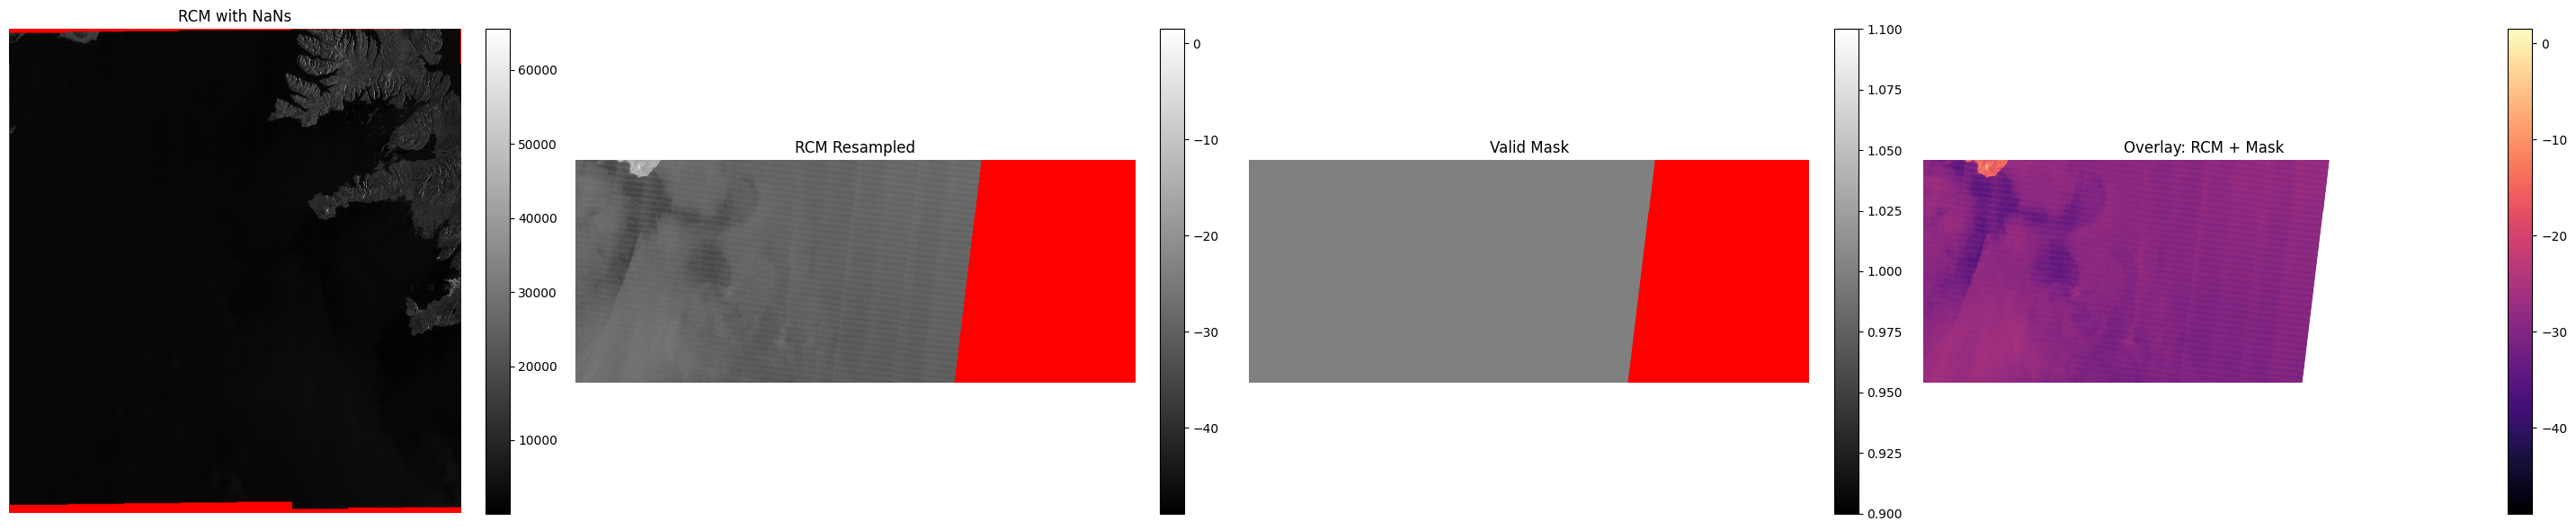

In [8]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import matplotlib.cm as cm
from matplotlib.colors import Normalize


sentinel_nc = "./train_dataset/S1B_EW_GRDM_1SDH_20210521T082226_20210521T082251_027000_0339C1_A16C_icechart_dmi_202105210825_SouthEast_RIC.nc"
imagery_dir = "./RCM/447_RCM/RCM1_OK1464315_PK1633216_1_SC50MD_20210521_075316_HH_HV_GRD/RCM1_OK1464315_PK1633216_1_SC50MD_20210521_075316_HH_HV_GRD/calibrated_imagery/"

ds = Dataset(sentinel_nc, "r")
s1_img = ds.variables["nersc_sar_primary"][:]
ds.close()

def load_tif_by_suffix(folder, suffix):
    for f in os.listdir(folder):
        if f.endswith(suffix):
            with rasterio.open(os.path.join(folder, f)) as src:
                return src.read(1)
    raise FileNotFoundError(f"No file ends with {suffix} in {folder}")

rcm_resampled = load_tif_by_suffix(imagery_dir, "sigma0_HH_dB_resampled_to_s1_grid_gcps.tif")
rcm_nan       = load_tif_by_suffix(imagery_dir.replace("calibrated_imagery", "imagery"), "_HH_nan.tif")
rcm_mask      = load_tif_by_suffix(imagery_dir.replace("calibrated_imagery", "sentinel_mask"), "_sigma0_HH_dB_resampled_to_s1_grid_gcps_valid_mask.tif")

# create overlay
overlay = np.copy(rcm_resampled)
overlay[np.isnan(overlay)] = np.nanmin(rcm_resampled)
overlay_img = np.ma.masked_where(rcm_mask == 0, overlay)

# Create masked versions
masked_images = [
    np.ma.masked_invalid(rcm_nan),
    np.ma.masked_invalid(rcm_resampled),
    np.ma.masked_where(rcm_mask == 0, rcm_mask),
    overlay_img
]

# Custom colormap with red for NaNs
gray_red = cm.get_cmap('gray').copy()
gray_red.set_bad(color='red')


fig, axes = plt.subplots(1, 4, figsize=(30, 6))
titles = ["RCM with NaNs", "RCM Resampled", "Valid Mask", "Overlay: RCM + Mask"]
for ax, img, title in zip(axes, masked_images, titles):
    im = ax.imshow(img, cmap=gray_red if title != "Overlay: RCM + Mask" else "magma")
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


Update the .nc files with new variables (RCM SAR images + Masks + geo info)

In [19]:
"""
This code loads raw and calibrated RCM SAR data, non-overlap masks, and metadata for each matched Sentinel-1 scene and appends them to the corresponding Sentinel-1 NetCDF file.  
It extracts and stores RCM tie-point geolocation (lat/lon), pixel coordinates, and incidence angle data from XML metadata.  
"""
def load_geotiff(filepath):
    with rasterio.open(filepath) as src:
        return src.read(1)
 
matched_rcm_folders = set()
for rcm_path in best_RCM_match:
    parts = os.path.normpath(rcm_path).split(os.sep)
    rcm_folder = parts[-2] 
    matched_rcm_folders.add(rcm_folder)

matched_pairs = []

for sentinel_scene in sentinel_footprints:
    rcm_folder = sentinel_scene['rcm_folder']
    base_name = sentinel_scene['base_name']
    nc_path = os.path.join("./train_dataset", base_name)

    matched_pairs.append((sentinel_scene, nc_path))

print(matched_pairs)
output_dir = "new_train_dataset"
os.makedirs(output_dir, exist_ok=True)
 
for sentinel_scene, nc_path in matched_pairs:
    rcm_folder = sentinel_scene['rcm_folder']
    base_name = sentinel_scene['base_name']
    print(rcm_folder,base_name )
 
    rcm_scene_path = next((p for p in best_RCM_match if rcm_folder in p), None)
    parts = os.path.normpath(rcm_scene_path).split(os.sep)
    rcm_scene = parts[-1]
    full_rcm_path = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
 
    cal_imagery_folder = os.path.join(full_rcm_path,rcm_scene, 'calibrated_imagery')
    sar_RCM_HH_cor_cal = next((os.path.join(cal_imagery_folder, f) for f in os.listdir(cal_imagery_folder) if f.endswith("_nan_sigma0_HH_dB_resampled_to_s1_grid_gcps.tif")), None)
    sar_RCM_HV_cor_cal = next((os.path.join(cal_imagery_folder, f) for f in os.listdir(cal_imagery_folder) if f.endswith("_nan_sigma0_HV_dB_resampled_to_s1_grid_gcps.tif")), None)
    orig_sar_RCM_HH = next((os.path.join(cal_imagery_folder, f) for f in os.listdir(cal_imagery_folder) if f.endswith("_nan_sigma0_HH_dB.tif")), None)
    orig_sar_RCM_HV = next((os.path.join(cal_imagery_folder, f) for f in os.listdir(cal_imagery_folder) if f.endswith("_nan_sigma0_HV_dB.tif")), None)
    mask_sentinel = next((os.path.join(full_rcm_path, rcm_scene, "sentinel_mask", f) for f in os.listdir(os.path.join(full_rcm_path, rcm_scene, "sentinel_mask")) if f.endswith("_nan_sigma0_HH_dB_resampled_to_s1_grid_gcps_valid_mask.tif")), None)

    orig_sar_RCM_HH = np.flipud(load_geotiff(orig_sar_RCM_HH))
    orig_sar_RCM_HV = np.flipud(load_geotiff(orig_sar_RCM_HV))
    sar_RCM_HH_cor_cal = load_geotiff(sar_RCM_HH_cor_cal)
    sar_RCM_HV_cor_cal = load_geotiff(sar_RCM_HV_cor_cal)
    mask_sentinel = (load_geotiff(mask_sentinel))
    
    ds = xr.open_dataset(nc_path)
    ds["orig_sar_RCM_HH"] = xr.DataArray(orig_sar_RCM_HH, dims=["sar_lines_rcm", "sar_samples_rcm"])
    ds["orig_sar_RCM_HV"] = xr.DataArray(orig_sar_RCM_HV, dims=["sar_lines_rcm", "sar_samples_rcm"])
    ds["sar_RCM_HH_cor_cal"] = xr.DataArray(sar_RCM_HH_cor_cal, dims=["sar_lines", "sar_samples"])
    ds["sar_RCM_HV_cor_cal"] = xr.DataArray(sar_RCM_HV_cor_cal, dims=["sar_lines", "sar_samples"])
    ds["mask_sentinel"] = xr.DataArray(mask_sentinel, dims=["sar_lines", "sar_samples"])
 
    product_xml = os.path.join(full_rcm_path, rcm_scene, 'metadata', 'product.xml')
    tree = ET.parse(product_xml)
    root = tree.getroot()
    ns = {'ns': root.tag.split('}')[0].strip('{')}
    tie_points = root.findall(".//ns:geolocationGrid/ns:imageTiePoint", namespaces=ns)
    lines, pixels, lats, lons = [], [], [], []
    for pt in tie_points:
        lines.append(float(pt.find(".//ns:imageCoordinate/ns:line", ns).text))
        pixels.append(float(pt.find(".//ns:imageCoordinate/ns:pixel", ns).text))
        lats.append(float(pt.find(".//ns:geodeticCoordinate/ns:latitude", ns).text))
        lons.append(float(pt.find(".//ns:geodeticCoordinate/ns:longitude", ns).text))

    angle_path = os.path.join(full_rcm_path, rcm_scene, 'metadata', 'calibration', 'incidenceAngles.xml')
    angle_tree = ET.parse(angle_path)
    angle_root = angle_tree.getroot()
    angle_ns = {'ns': angle_root.tag.split('}')[0].strip('{')}
    angles = np.array([float(a.text) for a in angle_root.findall(".//ns:angles", angle_ns)])    
    pixel_first = int(angle_root.find(".//ns:pixelFirstAnglesValue", angle_ns).text)
    step_size   = int(angle_root.find(".//ns:stepSize", angle_ns).text)
    pixel_idx   = pixel_first + np.arange(angles.size) * step_size
 
    dim_name = "sar_grid_points_rcm"
    ds["sar_grid_line_rcm"] = xr.DataArray(np.array(lines), dims=[dim_name])
    ds["sar_grid_sample_rcm"] = xr.DataArray(np.array(pixels), dims=[dim_name])
    ds["sar_grid_latitude_rcm"] = xr.DataArray(np.array(lats), dims=[dim_name])
    ds["sar_grid_longitude_rcm"] = xr.DataArray(np.array(lons), dims=[dim_name])

    dim_ang = "sar_pixel_rcm"
    ds = ds.assign_coords({dim_ang: pixel_idx})
    ds["sar_grid_incidenceangle_rcm"] = xr.DataArray(angles, dims=[dim_ang])
    out_path = os.path.join(output_dir, f"{base_name}")
    ds.to_netcdf(out_path, format="NETCDF4", engine="netcdf4")

[({'shapefile': '118_S1A_EW_GRDM_1SDH_20200312T102631_20200312T102731_031641_03A5A3_E76A_icechart_cis_SGRDIEA_20200312T1024Z_pl_a.zip', 'rcm_folder': '118_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200312T102631_20200312T102731_031641_03A5A3_E76A_icechart_cis_SGRDIEA_20200312T1024Z_pl_a.nc', 'footprint': <POLYGON ((-53.833 64.336, -54.249 64.389, -54.668 64.44, -55.087 64.49, -55...>}, './train_dataset\\S1A_EW_GRDM_1SDH_20200312T102631_20200312T102731_031641_03A5A3_E76A_icechart_cis_SGRDIEA_20200312T1024Z_pl_a.nc'), ({'shapefile': '119_S1A_EW_GRDM_1SDH_20200319T102035_20200319T102058_031743_03A932_FB85_icechart_cis_SGRDINFLD_20200319T1021Z_pl_a.zip', 'rcm_folder': '119_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200319T102035_20200319T102058_031743_03A932_FB85_icechart_cis_SGRDINFLD_20200319T1021Z_pl_a.nc', 'footprint': <POLYGON ((-56.227 56.279, -56.557 56.324, -56.887 56.368, -57.218 56.411, -...>}, './train_dataset\\S1A_EW_GRDM_1SDH_20200319T102035_20200319T102058_031743_03A932_FB85_icechart

In [26]:
# test new AI4Arctic
test_path = "./new_test_dataset/S1A_EW_GRDM_1SDH_20200217T102731_20200217T102833_031291_03998C_1768_icechart_cis_SGRDIEA_20200217T1024Z_pl_a.nc"
ds = xr.open_dataset(test_path)
print(ds.dims)
for var_name in ds.variables:
    print(f" - {var_name} → {ds[var_name].dims} | shape: {ds[var_name].shape}")

FrozenMappingWarningOnValuesAccess({'sar_lines': 10248, 'sar_samples': 10472, 'sar_grid_points': 462, 'polygon_codes': 41, '2km_grid_lines': 204, '2km_grid_samples': 209, 'sar_lines_rcm': 21742, 'sar_samples_rcm': 18169, 'sar_grid_points_rcm': 195, 'sar_pixel_rcm': 791})
 - nersc_sar_primary → ('sar_lines', 'sar_samples') | shape: (10248, 10472)
 - nersc_sar_secondary → ('sar_lines', 'sar_samples') | shape: (10248, 10472)
 - polygon_icechart → ('sar_lines', 'sar_samples') | shape: (10248, 10472)
 - distance_map → ('sar_lines', 'sar_samples') | shape: (10248, 10472)
 - sar_grid_line → ('sar_grid_points',) | shape: (462,)
 - sar_grid_sample → ('sar_grid_points',) | shape: (462,)
 - sar_grid_latitude → ('sar_grid_points',) | shape: (462,)
 - sar_grid_longitude → ('sar_grid_points',) | shape: (462,)
 - sar_grid_incidenceangle → ('sar_grid_points',) | shape: (462,)
 - sar_grid_height → ('sar_grid_points',) | shape: (462,)
 - polygon_codes → ('polygon_codes',) | shape: (41,)
 - btemp_6_9h → 